## Model Training (사용 X)

In [ ]:
import torch.nn as nn
from torchvision.transforms import ToTensor
import torch
from torch.utils.data import Dataset, DataLoader
from glob import glob
import os
from torch import optim
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image

class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super(ConvAutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, (40, 30)),
            nn.ReLU(),
            nn.MaxPool2d((3, 3)),
            nn.Conv2d(16, 32, (12, 9)),
            nn.ReLU(),
            nn.MaxPool2d(3, 3),
            nn.Conv2d(32, 64, (4, 3)),
            nn.ReLU(),
            nn.MaxPool2d((3, 3)),
            nn.Conv2d(64, 128, (4, 3)),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, (4, 3)),
            nn.ReLU(),
            nn.Upsample(scale_factor=3, mode="nearest"),
            nn.ConvTranspose2d(64, 32, (4, 3)),
            nn.ReLU(),
            nn.Upsample(scale_factor=3, mode="nearest"),
            nn.ConvTranspose2d(32, 16, (12, 9)),
            nn.ReLU(),
            nn.Upsample(scale_factor=3, mode="nearest"),
            nn.ConvTranspose2d(16, 3, (40, 30)),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
            # ★ 어떤 입력 크기든 출력 크기를 입력과 동일하게 강제
        if out.shape[-2:] != x.shape[-2:]:
            out = nn.functional.interpolate(out, size=x.shape[-2:], mode="nearest")

        return out
    

class Dataset_train(Dataset):
    def __init__(self, root_dir, transform=None): 
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path 
    
class Dataset_eval(Dataset):
    def __init__(self, root_dir, transform=None): 
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path 

    
# tensor -> numpy -> HWC 변환 함수
def imshow_tensor(img_tensor):
    img = img_tensor.detach().cpu().numpy()  # [C, H, W]
    img = img.transpose(1, 2, 0)  # [H, W, C]
    plt.imshow(img, cmap='gray' if img.shape[2]==1 else None)
    plt.axis('off')

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device =='cuda':
    torch.cuda.manual_seed_all(777)


train = '/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train'
val_normal = '/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal'
val_abnormal = '/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal'
transform = ToTensor()

train_folder = Dataset_train(root_dir=train, transform=transform)
normal_folder = Dataset_eval(root_dir=val_normal, transform=transform)
abnormal_folder = Dataset_eval(root_dir=val_abnormal, transform=transform)

train_loader = DataLoader(train_folder, batch_size=100, shuffle=True)
normal_loader = DataLoader(normal_folder, batch_size=100, shuffle=False)
abnormal_loader = DataLoader(abnormal_folder, batch_size=100, shuffle=False)

# 모델, 옵티마이저, criterion 설정
model = ConvAutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss()
lr_sche = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

model_path = '/root/ssd/yeonseo/ess/OCC_algorithm/model/OCC'
os.makedirs(model_path, exist_ok=True)

steps = 0
total_steps = len(train_loader)
num_epoch = 30

running_loss = 0.0
for epoch in range(num_epoch):
    model.train()
    for i, (inputs, paths) in enumerate(train_loader, 0):
        inputs = inputs.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if epoch % 10 == 9:
            plt.figure(figsize=(6, 3))

            # input
            plt.subplot(1, 2, 1)
            imshow_tensor(inputs[0]) # batch에서 첫 번째만 표시
            plt.title("Input")

            # output
            plt.subplot(1, 2, 2)
            imshow_tensor(outputs[0])
            plt.title("Output")

            plt.show()
            plt.close()
            print(f"{epoch} epoch training loss: {running_loss/30}")
            running_loss = 0.0
    lr_sche.step()

    save_path = os.path.join(model_path, f"epoch_{epoch+1}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

    normal_loss = 0.0
    with torch.no_grad():
        for inputs, _ in normal_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            normal_loss += loss.item() * inputs.size(0)
            
            plt.figure(figsize=(6, 3))

            # input
            plt.subplot(1, 2, 1)
            imshow_tensor(inputs[0])  # batch에서 첫 번째만 표시
            plt.title("Input")

            # output
            plt.subplot(1, 2, 2)
            imshow_tensor(outputs[0])
            plt.title("Output")
            plt.show()
            plt.close()

    normal_loss /= len(normal_loader.dataset)
    print(f"{epoch} epoch validation normal loss: {normal_loss}")
    model.eval()
    abnormal_loss = 0.0
    with torch.no_grad():
        for inputs, _ in abnormal_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            abnormal_loss += loss.item() * inputs.size(0)
            
            plt.figure(figsize=(6, 3))

            # input
            plt.subplot(1, 2, 1)
            imshow_tensor(inputs[0])  # batch에서 첫 번째만 표시
            plt.title("Input")

            # output
            plt.subplot(1, 2, 2)
            imshow_tensor(outputs[0])
            plt.title("Output")
            plt_save = "/".join(_[0].split("/")[-3:])
            save_path = os.path.join("/root/hdd/yeonseo/ess/validation_comparison", os.path.dirname(plt_save))
            os.makedirs(save_path, exist_ok=True)
            plt.savefig(os.path.join("/root/hdd/yeonseo/ess/validation_comparison", plt_save))
            plt.close()

    abnormal_loss /= len(abnormal_loader.dataset)
    print(f"{epoch} epoch validation abnormal loss: {abnormal_loss}")

## Model 확인

In [ ]:
import os
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt


# =========================
# Model (Skip connection + Upsample+Conv for sharper recon)
# =========================
class ConvAutoEncoder(nn.Module):
    """
    - nn.Sequential 스타일은 유지하되, 블록을 enc1~enc4 / dec1~dec4 형태로 구성
    - 스킵 연결(UNet 스타일)을 넣어서 디테일(고주파) 복원 강화 -> 더 선명해짐
    - ConvTranspose 대신 Upsample + Conv2d 사용 -> 테두리/체커보드 아티팩트 감소
    """
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        # Encoder blocks (stride=2 다운샘플, padding 유지)
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Decoder: Upsample + Conv, 그리고 skip concat
        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]

        e1 = self.enc1(x)   # 1/2
        e2 = self.enc2(e1)  # 1/4
        e3 = self.enc3(e2)  # 1/8
        e4 = self.enc4(e3)  # 1/16

        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        # 입력과 출력 크기 최종 보정
        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out


# =========================
# Dataset
# =========================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================
# Utils
# =========================
def imshow_tensor(img_tensor):
    img = img_tensor.detach().cpu().numpy()  # [C, H, W]
    img = img.transpose(1, 2, 0)            # [H, W, C]
    plt.imshow(img)
    plt.axis("off")


def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def gradient_loss(pred, target):
    """
    선명도 개선용: 엣지(gradient) 차이를 줄여서 흐림을 완화
    pred/target: [B, C, H, W]
    """
    dy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy_tgt  = target[:, :, 1:, :] - target[:, :, :-1, :]
    dx_tgt  = target[:, :, :, 1:] - target[:, :, :, :-1]
    return (dx_pred - dx_tgt).abs().mean() + (dy_pred - dy_tgt).abs().mean()


# =========================
# Main
# =========================
if __name__ == "__main__":
    # ---- 설정: 여기만 바꾸면 됨 ----
    USE_SUBSET = False                 # True: 적은 데이터로 sanity check / False: 전체 train 학습
    SUBSET_SIZE = 32                  # train subset 이미지 수

    USE_VAL_SUBSET = True            # True: val도 일부만 사용 / False: 전체 val 사용
    VAL_SUBSET_SIZE_NORMAL = 64       # normal val subset 이미지 수
    VAL_SUBSET_SIZE_ABNORMAL = 64     # abnormal val subset 이미지 수

    BATCH_SIZE = 100                    # train batch size
    VAL_BATCH_SIZE = 64               # val batch size
    NUM_EPOCH = 30
    LR = 0.001
    SEED = 777

    # 선명도 관련 loss 가중치 (너무 크면 거칠어질 수 있음)
    LAMBDA_GRAD = 0.10                # 0.05~0.15 사이 추천

    # 모델 채널 (크면 더 표현력↑, 메모리/시간↑)
    BASE_CH = 48                      # 더 선명하게 원하면 48 또는 64로 올려보기

    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    model_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck"
    os.makedirs(model_path, exist_ok=True)

    # (선택) 특정 GPU 고정
    os.environ["CUDA_VISIBLE_DEVICES"] = "1"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    transform = ToTensor()

    # ---- dataset 로드 ----
    train_folder = ImgDataset(root_dir=train, transform=transform)
    normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
    abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

    print("train images:", len(train_folder))
    print("normal images:", len(normal_folder))
    print("abnormal images:", len(abnormal_folder))
    if len(train_folder) > 0:
        print("train example path:", train_folder[0][1])

    # ---- Subset 적용 (train) ----
    if USE_SUBSET:
        train_dataset = make_subset(train_folder, SUBSET_SIZE, seed=SEED)
        print(f"[Train Subset ON] train subset size = {len(train_dataset)}")
    else:
        train_dataset = train_folder
        print(f"[Train Subset OFF] train full size = {len(train_dataset)}")

    # ---- Subset 적용 (val) ----
    if USE_VAL_SUBSET:
        normal_dataset = make_subset(normal_folder, VAL_SUBSET_SIZE_NORMAL, seed=SEED)
        abnormal_dataset = make_subset(abnormal_folder, VAL_SUBSET_SIZE_ABNORMAL, seed=SEED + 1)
        print(f"[Val Subset ON] normal subset size = {len(normal_dataset)}")
        print(f"[Val Subset ON] abnormal subset size = {len(abnormal_dataset)}")
    else:
        normal_dataset = normal_folder
        abnormal_dataset = abnormal_folder
        print(f"[Val Subset OFF] normal full size = {len(normal_dataset)}")
        print(f"[Val Subset OFF] abnormal full size = {len(abnormal_dataset)}")

    # ---- dataloader ----
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    normal_loader = DataLoader(normal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False)
    abnormal_loader = DataLoader(abnormal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False)

    # ---- model / optim ----
    model = ConvAutoEncoder(base_ch=BASE_CH).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.L1Loss()
    lr_sche = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    # ---- train ----
    for epoch in range(NUM_EPOCH):
        model.train()
        running_loss = 0.0

        for i, (inputs, paths) in enumerate(train_loader):
            inputs = inputs.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # 기본 L1 + 선명도(gradient) loss
            l1 = criterion(outputs, inputs)
            g  = gradient_loss(outputs, inputs)
            loss = (1.0 - LAMBDA_GRAD) * l1 + LAMBDA_GRAD * g

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        lr_sche.step()

        avg_train_loss = running_loss / max(1, len(train_loader))
        print(f"[Epoch {epoch+1}/{NUM_EPOCH}] train loss: {avg_train_loss:.6f}")

        # ---- 시각화: 매 10 epoch마다 1장 확인 ----
        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                inputs, _ = next(iter(train_loader))
                inputs = inputs.to(device)
                outputs = model(inputs)

            plt.figure(figsize=(6, 3))
            plt.subplot(1, 2, 1)
            imshow_tensor(inputs[0])
            plt.title("Input")
            plt.subplot(1, 2, 2)
            imshow_tensor(outputs[0])
            plt.title("Output")
            plt.tight_layout()
            plt.show()
            plt.close()

        # ---- save ----
        save_path = os.path.join(model_path, f"epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Model saved to {save_path}")

        # ---- validation: normal ----
        model.eval()
        normal_loss = 0.0
        with torch.no_grad():
            for inputs, _ in normal_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)

                l1 = criterion(outputs, inputs)
                g  = gradient_loss(outputs, inputs)
                loss = (1.0 - LAMBDA_GRAD) * l1 + LAMBDA_GRAD * g

                normal_loss += loss.item() * inputs.size(0)

        if len(normal_loader.dataset) > 0:
            normal_loss /= len(normal_loader.dataset)
        print(f"[Epoch {epoch+1}] validation normal loss: {normal_loss:.6f}")
        plt.figure(figsize=(6, 3))

        # input
        plt.subplot(1, 2, 1)
        imshow_tensor(inputs[0])  # batch에서 첫 번째만 표시
        plt.title("Input")

        # output
        plt.subplot(1, 2, 2)
        imshow_tensor(outputs[0])
        plt.title("Output")
        plt_save = "/".join(_[0].split("/")[-3:])
        save_path = os.path.join("/root/hdd/yeonseo/ess/OCC_Algorithm/validation_comparision/nomal", f"epoch_{epoch+1}", os.path.dirname(plt_save))
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, plt_save.split("/")[-1]))
        plt.close()


        # ---- validation: abnormal ----
        abnormal_loss = 0.0
        with torch.no_grad():
            for inputs, _ in abnormal_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)

                l1 = criterion(outputs, inputs)
                g  = gradient_loss(outputs, inputs)
                loss = (1.0 - LAMBDA_GRAD) * l1 + LAMBDA_GRAD * g

                abnormal_loss += loss.item() * inputs.size(0)

        if len(abnormal_loader.dataset) > 0:
            abnormal_loss /= len(abnormal_loader.dataset)
        print(f"[Epoch {epoch+1}] validation abnormal loss: {abnormal_loss:.6f}")
        plt.figure(figsize=(6, 3))

        # input
        plt.subplot(1, 2, 1)
        imshow_tensor(inputs[0])  # batch에서 첫 번째만 표시
        plt.title("Input")

        # output
        plt.subplot(1, 2, 2)
        imshow_tensor(outputs[0])
        plt.title("Output")
        plt_save = "/".join(_[0].split("/")[-3:])
        save_path = os.path.join("/root/hdd/yeonseo/ess/OCC_Algorithm/validation_comparision/abnomal", f"epoch_{epoch+1}", os.path.dirname(plt_save))
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, plt_save.split("/")[-1]))
        plt.close()


## Model (ConvAutoencoder)

In [13]:
# =========================
# Model (Skip connection + Upsample+Conv for sharper recon)
# =========================
class ConvAutoEncoder(nn.Module):
    """
    - nn.Sequential 스타일은 유지하되, 블록을 enc1~enc4 / dec1~dec4 형태로 구성
    - 스킵 연결(UNet 스타일)을 넣어서 디테일(고주파) 복원 강화 -> 더 선명해짐
    - ConvTranspose 대신 Upsample + Conv2d 사용 -> 테두리/체커보드 아티팩트 감소
    """
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        # Encoder blocks (stride=2 다운샘플, padding 유지)
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Decoder: Upsample + Conv, 그리고 skip concat
        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]

        e1 = self.enc1(x)   # 1/2
        e2 = self.enc2(e1)  # 1/4
        e3 = self.enc3(e2)  # 1/8
        e4 = self.enc4(e3)  # 1/16

        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        # 입력과 출력 크기 최종 보정
        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out


## OCC Algorithm

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import LocalOutlierFactor


class IsoForest:
    def __init__(self, X_train):
        self.X_train = X_train
        self.model = IsolationForest()
    
    def fit(self, X_val):
        self.model.fit(self.X_train)
        self.score = self.model.score_samples(X_val).reshape(-1, 1) * -1

    def predict(self, X_test):
        self.final_score = self.model.score_samples(X_test).reshape(-1, 1) * -1

    def normalization(self):
        scaler = MinMaxScaler()
        scaler.fit(self.score)
        self.isoforest_score = scaler.transform(self.final_score)

    def ROC_Cal(self, all_test, score):
        auc_df = pd.Series(data=np.zeros(1), index=["all"])
        X = all_test[:, 0]
        y = all_test[:, 1]
        fpr, tpr, thresholds = roc_curve(y_true=y, y_score=score, pos_label=1)
        auc_df["all"] = auc(fpr, tpr)
        
        return auc_df

class LOF:
    def __init__(self, X_train, param=None, random_state=None):
        self.X_train = X_train

        # param 예시: [n_neighbors, contamination]
        if param is not None:
            n_neighbors = int(param[0])
            contamination = param[1]
        else:
            n_neighbors = 20
            contamination = "auto"

        self.model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=True,         # 중요!
            n_jobs=-1
        )

        self.scaler = None
        self.score = None
        self.final_score = None
        self.lof_score = None

    def fit(self, X_val):
        self.model.fit(self.X_train)
        # decision_function: 클수록 정상(0이 threshold). anomaly score로 뒤집기
        self.score = (-self.model.decision_function(X_val)).reshape(-1, 1)

    def predict(self, X_test):
        self.final_score = (-self.model.decision_function(X_test)).reshape(-1, 1)

    def normalization(self, clip_01=False):
        self.scaler = MinMaxScaler()
        self.scaler.fit(self.score)  # 보통 val로 fit (네 구조 유지)
        self.lof_score = self.scaler.transform(self.final_score)
        if clip_01:
            self.lof_score = np.clip(self.lof_score, 0.0, 1.0)

    def ROC_Cal(self, all_test, score):
        auc_df = pd.Series(data=np.zeros(1), index=["all"])
        y = np.asarray(all_test[:, 1]).ravel()
        score = np.asarray(score).ravel()

        fpr, tpr, _ = roc_curve(y_true=y, y_score=score, pos_label=1)
        auc_df["all"] = auc(fpr, tpr)
        return auc_df


class MoG:
    def __init__(self, X_train, param=None, random_state=42):
        self.X_train = X_train

        # param 예시: [n_components, covariance_type]
        if param is not None:
            n_components = int(param[0])
            covariance_type = param[1] if len(param) > 1 else "full"
        else:
            n_components = 1
            covariance_type = "full"

        self.model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            reg_covar=1e-6,
            random_state=random_state
        )

        self.scaler = None
        self.score = None
        self.final_score = None
        self.mog_score = None

    def fit(self, X_val):
        self.model.fit(self.X_train)
        # log p(x) -> NLL로 뒤집어서 "클수록 이상" 점수화
        self.score = (-self.model.score_samples(X_val)).reshape(-1, 1)

    def predict(self, X_test):
        self.final_score = (-self.model.score_samples(X_test)).reshape(-1, 1)

    def normalization(self, clip_01=False):
        self.scaler = MinMaxScaler()
        self.scaler.fit(self.score)  # 네 구조 유지
        self.mog_score = self.scaler.transform(self.final_score)
        if clip_01:
            self.mog_score = np.clip(self.mog_score, 0.0, 1.0)

    def ROC_Cal(self, all_test, score):
        auc_df = pd.Series(data=np.zeros(1), index=["all"])
        y = np.asarray(all_test[:, 1]).ravel()
        score = np.asarray(score).ravel()

        fpr, tpr, _ = roc_curve(y_true=y, y_score=score, pos_label=1)
        auc_df["all"] = auc(fpr, tpr)
        return auc_df

def extract_latent(model, loader, device):
    model.eval()
    zs = []
    ys = []
    for batch in loader:
        if isinstance(batch, (list, tuple)) and len(batch) == 2:
            x, y = batch
            ys.append(y.numpy())
        else:
            x = batch
        x = x.to(device)
        _, z = model(x)
        zs.append(z.detach().cpu().numpy())
    Z = np.concatenate(zs, axis=0)
    Y = None if len(ys) == 0 else np.concatenate(ys, axis=0)
    return Z, Y

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture


# -----------------------
# 1) 모델별 "이상 점수" 계산 (클수록 이상)
# -----------------------
def anomaly_score(model, X, occ_type: str):
    """
    X: (n, d)
    return: (n,) anomaly score (higher = more anomalous)
    """
    if occ_type == "isoforest":
        # score_samples: higher = more normal -> flip
        s = -model.score_samples(X)
    elif occ_type == "lof":
        # decision_function: higher = more normal -> flip
        s = -model.decision_function(X)
    elif occ_type == "gmm":
        # score_samples: log p(x) -> NLL = -log p(x)
        s = -model.score_samples(X)
    else:
        raise ValueError("occ_type must be one of: isoforest, lof, gmm")
    return np.asarray(s).ravel()


# -----------------------
# 2) threshold 설정 (정상 val의 상위 q만 이상으로)
# -----------------------
def pick_threshold_from_val(val_scores, q=0.995):
    """
    q=0.995 => 정상 val 기준 상위 0.5%만 이상으로 뜨게
    """
    v = np.asarray(val_scores).ravel()
    return float(np.quantile(v, q))


# -----------------------
# 3) 학습(스케일러 + OCC + threshold)
# -----------------------
def train_occ(train_latents, val_latents, occ_type="isoforest", q=0.995, random_state=42, occ_params=None):
    """
    train_latents: (N_train, d)
    val_latents  : (N_val, d)  (정상만 권장)
    occ_params: 모델별 파라미터 dict (선택)
    """
    train_latents = np.asarray(train_latents)
    val_latents = np.asarray(val_latents)

    # (A) latent 스케일링 (추천: LOF/GMM 필수급, iForest도 통일 위해 추천)
    scaler = StandardScaler()
    Ztr = scaler.fit_transform(train_latents)
    Zva = scaler.transform(val_latents)

    # (B) OCC 모델 생성/학습
    occ_params = occ_params or {}

    if occ_type == "isoforest":
        model = IsolationForest(random_state=random_state, n_jobs=-1, **occ_params)
        model.fit(Ztr)

    elif occ_type == "lof":
        # novelty=True 필수 (그래야 새 샘플에 대해 decision_function/score 가능)
        model = LocalOutlierFactor(novelty=True, n_jobs=-1, **occ_params)
        model.fit(Ztr)

    elif occ_type == "gmm":
        model = GaussianMixture(random_state=random_state, **occ_params)
        model.fit(Ztr)

    else:
        raise ValueError("occ_type must be one of: isoforest, lof, gmm")

    # (C) val 점수로 threshold 결정
    val_scores = anomaly_score(model, Zva, occ_type=occ_type)
    threshold = pick_threshold_from_val(val_scores, q=q)

    return scaler, model, threshold


# -----------------------
# 4) 날짜별로 들어오는 latent에 대해 이상 날짜 찾기
# -----------------------
def detect_anomaly_dates(daily_latents: dict, scaler, model, threshold, occ_type="isoforest"):
    """
    daily_latents: {"YYYY-MM-DD": latent(d,) or (1,d)}
    return:
      - df: date, score, is_anomaly
      - anomaly_dates: 이상으로 판단된 날짜 리스트
    """
    rows = []
    for date_str, z in daily_latents.items():
        z = np.asarray(z)
        if z.ndim == 1:
            z = z.reshape(1, -1)  # (1,d)

        z_s = scaler.transform(z)  # (1,d)
        score = float(anomaly_score(model, z_s, occ_type=occ_type)[0])
        is_anom = (score >= threshold)

        rows.append({"date": date_str, "score": score, "is_anomaly": is_anom})

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    anomaly_dates = df.loc[df["is_anomaly"], "date"].tolist()
    return df, anomaly_dates


# -----------------------
# 5) 예시 사용
# -----------------------
if __name__ == "__main__":
    # 예시 latent (실제로는 CAE에서 미리 뽑아둔 latent를 넣으면 됨)
    d = 16
    train_latents = np.random.randn(2000, d)          # 정상
    val_latents   = np.random.randn(500, d)           # 정상

    daily_latents = {
        "2025-12-01": np.random.randn(d),
        "2025-12-02": np.random.randn(d),
        "2025-12-03": np.random.randn(d) + 4.0,       # 이상 흉내
        "2025-12-04": np.random.randn(d),
    }

    # (1) OCC 학습 + threshold
    scaler, model, thr = train_occ(
        train_latents, val_latents,
        occ_type="isoforest",          # "lof" 또는 "gmm"로 바꾸면 됨
        q=0.995,
        occ_params={}                  # 필요 시 파라미터 넣기
    )

    # (2) 날짜별 판정
    df, anomaly_dates = detect_anomaly_dates(daily_latents, scaler, model, thr, occ_type="isoforest")

    print(df)
    print("Anomaly dates:", anomaly_dates)


In [4]:
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture


# =========================================================
# [SECTION 1] Model (Your CAE 그대로 + latent 추출용 encode() 추가)
# =========================================================
class ConvAutoEncoder(nn.Module):
    """
    - Encoder/Decoder (skip + upsample conv)
    - forward(): recon 반환
    - encode(): latent vector 반환 (OCC 입력으로 사용할 벡터)
    """
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        # Encoder blocks
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Decoder blocks (skip concat)
        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 입력 크기 기억 (최종 출력 보정용)
        h, w = x.shape[-2], x.shape[-1]

        # encode 과정에서 skip feature 확보
        e1 = self.enc1(x)   # 1/2
        e2 = self.enc2(e1)  # 1/4
        e3 = self.enc3(e2)  # 1/8
        e4 = self.enc4(e3)  # 1/16
        b = self.bottleneck(e4)

        # decode (skip concat)
        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        """
        OCC에 넣을 latent vector 생성.
        - e4 또는 bottleneck(b)을 pooling해서 1D 벡터로 만듦.
        - 여기서는 bottleneck(b) 사용.
        """
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)               # (B, C, H', W')

        # Global Average Pooling -> (B, C)
        z = b.mean(dim=(2, 3))
        return z


# =========================================================
# [SECTION 2] Dataset (Your ImgDataset 그대로)
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Utils (subset / visualization / loss / date parsing)
# =========================================================
def imshow_tensor(img_tensor):
    img = img_tensor.detach().cpu().numpy()  # [C, H, W]
    img = img.transpose(1, 2, 0)            # [H, W, C]
    plt.imshow(img)
    plt.axis("off")


def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def gradient_loss(pred, target):
    dy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy_tgt  = target[:, :, 1:, :] - target[:, :, :-1, :]
    dx_tgt  = target[:, :, :, 1:] - target[:, :, :, :-1]
    return (dx_pred - dx_tgt).abs().mean() + (dy_pred - dy_tgt).abs().mean()


def extract_date_str(path: str) -> str:
    """
    path에서 날짜를 뽑아서 'YYYY-MM-DD'로 반환
    - 우선순위: YYYY-MM-DD / YYYY_MM_DD / YYYYMMDD
    - 없으면 파일명(stem) 사용
    """
    stem = os.path.splitext(os.path.basename(path))[0]

    m = re.search(r"(20\d{2})[-_](\d{2})[-_](\d{2})", path)
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"

    m = re.search(r"(20\d{2})(\d{2})(\d{2})", path)
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"

    return stem


# =========================================================
# [SECTION 4] Latent Extraction (train/val/test 어디든 공통)
# =========================================================
@torch.no_grad()
def extract_latents_from_loader(model, loader, device):
    """
    loader에서 (img, path)를 받아 model.encode(img)로 latent 추출
    return:
      Z: (N, latent_dim)
      dates: (N,) path에서 뽑은 날짜 문자열
      paths: (N,) 원본 path
    """
    model.eval()
    zs, dates, paths = [], [], []

    for x, p in loader:
        x = x.to(device)
        z = model.encode(x)                    # (B, latent_dim)
        zs.append(z.detach().cpu().numpy())

        for pp in p:
            paths.append(pp)
            dates.append(extract_date_str(pp))

    Z = np.concatenate(zs, axis=0) if len(zs) > 0 else np.zeros((0, 1), dtype=np.float32)
    return Z, np.array(dates), np.array(paths)


# =========================================================
# [SECTION 5] OCC: 모델 생성/학습/스코어/threshold
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    """
    occ_type: "isoforest" | "lof" | "gmm"
    params: dict 형태로 sklearn 모델 파라미터 추가 가능
    """
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        # novelty=True 필수: train fit 후 새로운 샘플 score 가능
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        # params 예: {"n_components":4, "covariance_type":"full"}
        if "random_state" not in params:
            params["random_state"] = seed
        return GaussianMixture(**params)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(model, X, occ_type: str):
    """
    점수는 항상 '클수록 이상'이 되도록 통일
    """
    if occ_type == "isoforest":
        return (-model.score_samples(X)).ravel()
    if occ_type == "lof":
        return (-model.decision_function(X)).ravel()
    if occ_type == "gmm":
        return (-model.score_samples(X)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    """
    정상/비정상 val이 있으니 threshold는 F1 max로 선택하는게 보통 가장 직관적
    """
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))

        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


# =========================================================
# [SECTION 6] AE Training (너 코드 흐름 유지 + best 저장 옵션)
# =========================================================
def train_ae(
    model, train_loader, normal_loader, abnormal_loader, device,
    num_epoch=30, lr=1e-3, lambda_grad=0.10,
    model_path="./model", save_every_epoch=True
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    lr_sche = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    # best 기준: normal val loss 최소 (원하면 다른 기준으로 바꿔도 됨)
    best_normal = float("inf")
    best_path = os.path.join(model_path, "best_ae.pth")

    for epoch in range(num_epoch):
        # ---------------------------
        # (1) Train
        # ---------------------------
        model.train()
        running_loss = 0.0

        for inputs, _paths in train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)

            l1 = criterion(outputs, inputs)
            g  = gradient_loss(outputs, inputs)
            loss = (1.0 - lambda_grad) * l1 + lambda_grad * g

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        lr_sche.step()
        avg_train_loss = running_loss / max(1, len(train_loader))
        print(f"[Epoch {epoch+1}/{num_epoch}] train loss: {avg_train_loss:.6f}")

        # ---------------------------
        # (2) Validation: normal
        # ---------------------------
        model.eval()
        normal_loss = 0.0
        with torch.no_grad():
            for inputs, _ in normal_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)

                l1 = criterion(outputs, inputs)
                g  = gradient_loss(outputs, inputs)
                loss = (1.0 - lambda_grad) * l1 + lambda_grad * g

                normal_loss += loss.item() * inputs.size(0)

        if len(normal_loader.dataset) > 0:
            normal_loss /= len(normal_loader.dataset)
        print(f"[Epoch {epoch+1}] val normal loss: {normal_loss:.6f}")

        # ---------------------------
        # (3) Validation: abnormal (참고용 출력)
        # ---------------------------
        abnormal_loss = 0.0
        with torch.no_grad():
            for inputs, _ in abnormal_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)

                l1 = criterion(outputs, inputs)
                g  = gradient_loss(outputs, inputs)
                loss = (1.0 - lambda_grad) * l1 + lambda_grad * g

                abnormal_loss += loss.item() * inputs.size(0)

        if len(abnormal_loader.dataset) > 0:
            abnormal_loss /= len(abnormal_loader.dataset)
        print(f"[Epoch {epoch+1}] val abnormal loss: {abnormal_loss:.6f}")

        # ---------------------------
        # (4) Save (epoch별 + best)
        # ---------------------------
        if save_every_epoch:
            ep_path = os.path.join(model_path, f"epoch_{epoch+1}.pth")
            torch.save(model.state_dict(), ep_path)
            print(f"Model saved to {ep_path}")

        if normal_loss < best_normal:
            best_normal = normal_loss
            torch.save(model.state_dict(), best_path)
            print(f"[BEST] saved to {best_path} (best normal loss={best_normal:.6f})")

    return best_path


# =========================================================
# [SECTION 7] MAIN (AE 학습 + OCC + 날짜별 이상 날짜 출력)
# =========================================================
if __name__ == "__main__":

    # ---------------------------
    # (0) 설정
    # ---------------------------
    USE_SUBSET = False
    SUBSET_SIZE = 32

    USE_VAL_SUBSET = False
    VAL_SUBSET_SIZE_NORMAL = 64
    VAL_SUBSET_SIZE_ABNORMAL = 64

    BATCH_SIZE = 100
    VAL_BATCH_SIZE = 64
    NUM_EPOCH = 30
    LR = 0.001
    SEED = 777

    LAMBDA_GRAD = 0.10
    BASE_CH = 48

    # OCC 설정
    OCC_TYPE = "lof"   # "lof" / "gmm"
    OCC_PARAMS = {}          # 예: {"n_estimators":300} or LOF {"n_neighbors":20} or GMM {"n_components":4}

    # threshold를 F1로 고를지, quantile로 고를지
    USE_F1_THRESHOLD = True
    VAL_QUANTILE = 0.995     # (F1 안 쓰면) 정상 val의 상위 0.5%를 이상으로

    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    model_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck"
    os.makedirs(model_path, exist_ok=True)

    os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    transform = ToTensor()

    # ---------------------------
    # (1) dataset 로드
    # ---------------------------
    train_folder = ImgDataset(root_dir=train, transform=transform)
    normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
    abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

    print("train images:", len(train_folder))
    print("normal images:", len(normal_folder))
    print("abnormal images:", len(abnormal_folder))
    if len(train_folder) > 0:
        print("train example path:", train_folder[0][1])

    # ---------------------------
    # (2) subset 적용 (선택)
    # ---------------------------
    if USE_SUBSET:
        train_dataset = make_subset(train_folder, SUBSET_SIZE, seed=SEED)
        print(f"[Train Subset ON] train subset size = {len(train_dataset)}")
    else:
        train_dataset = train_folder
        print(f"[Train Subset OFF] train full size = {len(train_dataset)}")

    if USE_VAL_SUBSET:
        normal_dataset = make_subset(normal_folder, VAL_SUBSET_SIZE_NORMAL, seed=SEED)
        abnormal_dataset = make_subset(abnormal_folder, VAL_SUBSET_SIZE_ABNORMAL, seed=SEED + 1)
        print(f"[Val Subset ON] normal subset size = {len(normal_dataset)}")
        print(f"[Val Subset ON] abnormal subset size = {len(abnormal_dataset)}")
    else:
        normal_dataset = normal_folder
        abnormal_dataset = abnormal_folder
        print(f"[Val Subset OFF] normal full size = {len(normal_dataset)}")
        print(f"[Val Subset OFF] abnormal full size = {len(abnormal_dataset)}")

    # ---------------------------
    # (3) dataloader
    # ---------------------------
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    normal_loader = DataLoader(normal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    abnormal_loader = DataLoader(abnormal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    # ---------------------------
    # (4) CAE 모델 생성 & 학습
    # ---------------------------
    model = ConvAutoEncoder(base_ch=BASE_CH).to(device)

    # best_ae_path = train_ae(
    #     model=model,
    #     train_loader=train_loader,
    #     normal_loader=normal_loader,
    #     abnormal_loader=abnormal_loader,
    #     device=device,
    #     num_epoch=NUM_EPOCH,
    #     lr=LR,
    #     lambda_grad=LAMBDA_GRAD,
    #     model_path=model_path,
    #     save_every_epoch=True
    # )

    # best 모델 로드 (OCC에 쓰는 latent는 best 기준 추천)
    best_ae_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_12.pth"
    model.load_state_dict(torch.load(best_ae_path, map_location=device))
    model.to(device)
    model.eval()
    print("Loaded best AE:", best_ae_path)

    # ---------------------------
    # (5) latent 추출 (train/val normal/val abnormal)
    # ---------------------------
    # 여기서는 "subset 적용된 dataset" 기준으로 추출함 (위에서 subset이면 subset)
    # 날짜별로 보고 싶으면 val folder 전체를 쓰는 게 좋음.
    train_eval_loader = DataLoader(train_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    Z_tr, dates_tr, paths_tr = extract_latents_from_loader(model, train_eval_loader, device)
    Z_vn, dates_vn, paths_vn = extract_latents_from_loader(model, normal_loader, device)
    Z_va, dates_va, paths_va = extract_latents_from_loader(model, abnormal_loader, device)

    print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

    # ---------------------------
    # (6) latent 스케일링 (LOF/GMM에 특히 중요)
    # ---------------------------
    z_scaler = StandardScaler()
    Z_tr_s = z_scaler.fit_transform(Z_tr)
    Z_vn_s = z_scaler.transform(Z_vn)
    Z_va_s = z_scaler.transform(Z_va)

    # ---------------------------
    # (7) OCC 학습 (train latent로 fit)
    # ---------------------------
    occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
    occ.fit(Z_tr_s)

    # val 점수 산출
    s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)  # normal val score
    s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)  # abnormal val score

    # ---------------------------
    # (8) threshold 결정
    # ---------------------------
    if USE_F1_THRESHOLD:
        threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
        print(f"[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")
    else:
        threshold = float(np.quantile(s_vn, VAL_QUANTILE))
        print(f"[{OCC_TYPE}] threshold={threshold:.6f} (normal val quantile={VAL_QUANTILE})")

    # ---------------------------
    # (9) "날짜별로 어떤 날짜가 이상인지" 계산
    # ---------------------------
    # val normal + val abnormal 전체를 합쳐서 날짜별 결과를 보고 싶다면:
    Z_all_s = np.concatenate([Z_vn_s, Z_va_s], axis=0)
    dates_all = np.concatenate([dates_vn, dates_va], axis=0)
    paths_all = np.concatenate([paths_vn, paths_va], axis=0)
    gt_all = np.concatenate([np.zeros(len(dates_vn), dtype=int), np.ones(len(dates_va), dtype=int)], axis=0)

    scores_all = anomaly_score(occ, Z_all_s, OCC_TYPE)
    pred_all = (scores_all >= threshold).astype(int)

    df = pd.DataFrame({
        "date": dates_all,
        "path": paths_all,
        "score": scores_all,
        "pred_anomaly": pred_all,
        "gt": gt_all
    }).sort_values(["date", "score"], ascending=[True, False]).reset_index(drop=True)

    # (중요) 날짜별로 "하나만 들어온다"면 df 그대로 사용하면 됨.
    # 만약 같은 날짜에 여러 장이 있다면, 아래처럼 날짜 단위 집계해서 "그날 이상 여부"로 만들면 됨.
    df_day = df.groupby("date", as_index=False).agg(
        score_max=("score", "max"),
        pred_anomaly=("pred_anomaly", "max"),
        n=("date", "count")
    ).sort_values("date").reset_index(drop=True)

    anomaly_dates = df_day.loc[df_day["pred_anomaly"] == 1, "date"].tolist()

    print("\n===== Daily Result (date-level) =====")
    print(df_day.head(20))
    print("\nAnomaly dates:", anomaly_dates)

    # 저장
    df_path = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
    df_day_path = os.path.join(model_path, f"occ_{OCC_TYPE}_per_day.csv")
    df.to_csv(df_path, index=False)
    df_day.to_csv(df_day_path, index=False)
    print("Saved:", df_path)
    print("Saved:", df_day_path)

    # ---------------------------
    # (10) (선택) 이상 날짜의 샘플 몇 개 확인용
    # ---------------------------
    # 이상으로 분류된 상위 몇 개 파일을 뽑아서 보고 싶다면:
    top_anom = df[df["pred_anomaly"] == 1].head(10)
    print("\nTop anomaly samples:")
    print(top_anom[["date", "score", "path"]])


train images: 22968
normal images: 9537
abnormal images: 17340
train example path: /root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train/00321804(0002)/bx_sx_r10_m1/2023-11-25.png
[Train Subset OFF] train full size = 22968
[Val Subset OFF] normal full size = 9537
[Val Subset OFF] abnormal full size = 17340
Loaded best AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_12.pth


/tmp/ipykernel_3215640/3111134427.py:543: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ae_path, map_location=device))


latent shapes: (22968, 384) (9537, 384) (17340, 384)
[lof] threshold=0.114597 (val best F1=0.8213)

===== Daily Result (date-level) =====
          date  score_max  pred_anomaly    n
0   2022-02-01   4.052723             1  289
1   2022-02-02   4.054873             1  289
2   2022-02-03   4.604179             1  289
3   2022-02-04   4.653848             1  289
4   2022-02-05   4.420782             1  289
5   2022-02-06   4.454523             1  289
6   2022-02-07   4.288826             1  289
7   2022-02-08   4.355452             1  289
8   2022-02-09   4.356774             1  289
9   2022-02-10   4.286178             1  289
10  2022-02-11   4.284235             1  289
11  2022-02-12   4.718495             1  289
12  2022-02-13   5.034456             1  289
13  2022-02-14   5.155131             1  289
14  2022-02-15   4.718059             1  289
15  2022-02-16   3.713404             1  289
16  2022-02-17   4.578571             1  289
17  2022-02-18   4.239510             1  289
18  202

=== Per-file metrics ===
Confusion Matrix [[TN,FP],[FN,TP]]:
 [[ 8673   864]
 [ 1263 16077]]
Accuracy  : 0.9209
Precision : 0.9490
Recall    : 0.9272
F1        : 0.9380
ROC-AUC   : 0.9766
PR-AUC(AP): 0.9873


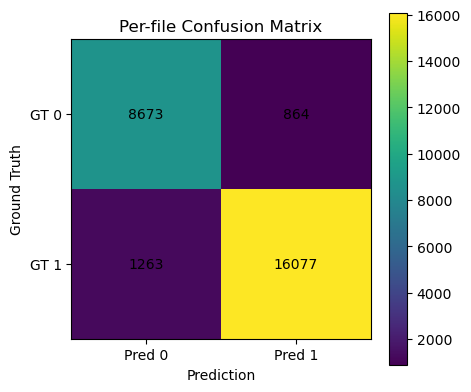

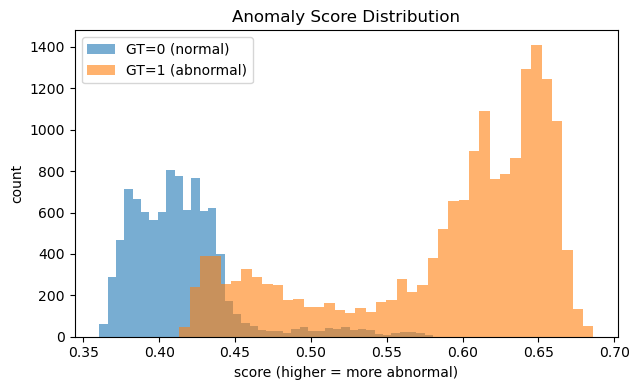

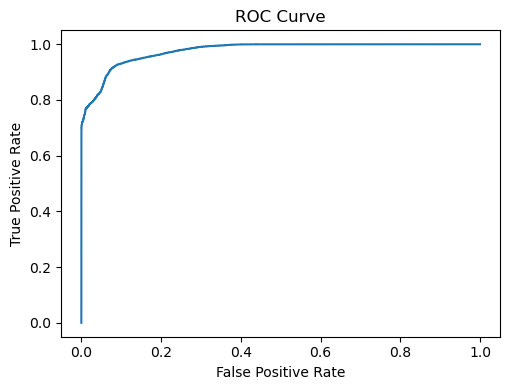

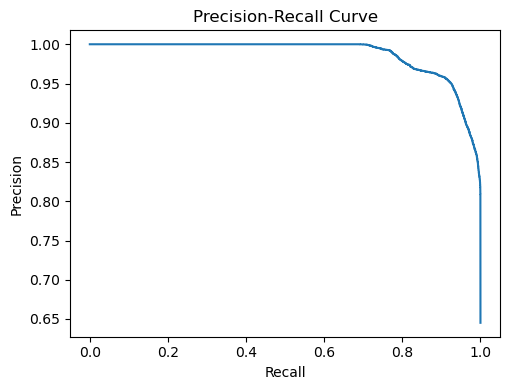

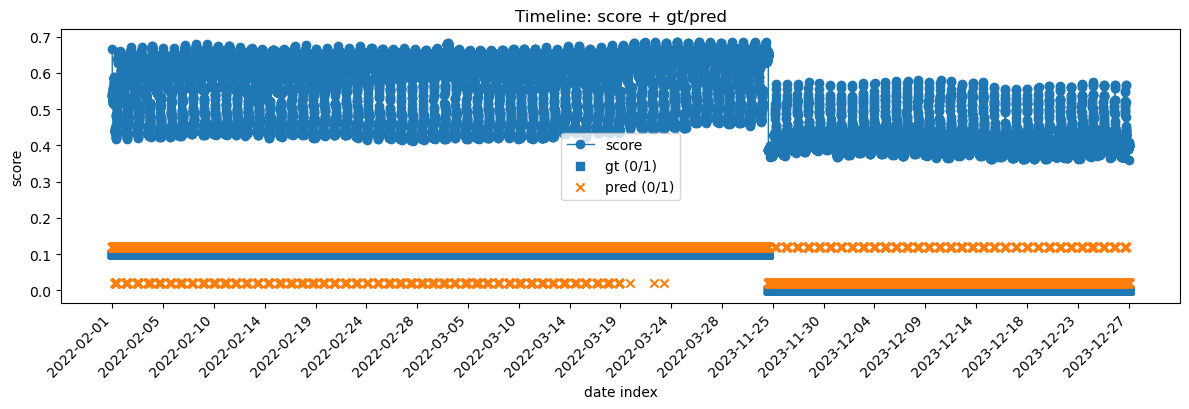

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

CSV_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_file_validation.csv"
THRESHOLD = None  # df에 pred가 이미 있으면 없어도 됨. (score로 pred 다시 만들 때만 사용)


# =========================
# [A] Load
# =========================
df = pd.read_csv(CSV_PATH)

# 컬럼 이름이 다를 수 있으니 안전하게 맞춰줌
# (네 파일 예시 기준: date, path, score, pred_anomaly, gt)
assert {"date", "path", "score"}.issubset(df.columns), df.columns

# pred / gt가 int가 아니면 변환
if "pred_anomaly" in df.columns:
    df["pred_anomaly"] = df["pred_anomaly"].astype(int)
if "gt" in df.columns:
    df["gt"] = df["gt"].astype(int)

# 날짜 정렬을 위해 datetime 변환 (실패하면 문자열 정렬 유지)
try:
    df["date_dt"] = pd.to_datetime(df["date"])
except Exception:
    df["date_dt"] = df["date"]


# =========================
# [B] (선택) score로 pred 다시 만들고 싶으면
# =========================
if THRESHOLD is not None:
    df["pred_anomaly"] = (df["score"] >= THRESHOLD).astype(int)


# =========================
# [C] Metrics (per-file)
# =========================
y_true = df["gt"].values
y_pred = df["pred_anomaly"].values
scores = df["score"].values

cm = confusion_matrix(y_true, y_pred)  # [[TN, FP],[FN, TP]]
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("=== Per-file metrics ===")
print("Confusion Matrix [[TN,FP],[FN,TP]]:\n", cm)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1        : {f1:.4f}")

# 점수 기반 지표(AUC)는 score가 "클수록 이상"이면 그대로 사용 가능
# gt가 0/1 모두 존재해야 계산 가능
if len(np.unique(y_true)) == 2:
    auc_roc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    print(f"ROC-AUC   : {auc_roc:.4f}")
    print(f"PR-AUC(AP): {ap:.4f}")


# =========================
# [D] Visualization 1: Confusion Matrix (matplotlib만 사용)
# =========================
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    fig = plt.figure(figsize=(4.8, 4.2))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["GT 0", "GT 1"])

    # 숫자 표시
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.ylabel("Ground Truth")
    plt.xlabel("Prediction")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, title="Per-file Confusion Matrix")


# =========================
# [E] Visualization 2: Score 분포(정상 vs 이상)
# =========================
def plot_score_hist(df):
    s0 = df[df["gt"] == 0]["score"].values
    s1 = df[df["gt"] == 1]["score"].values

    plt.figure(figsize=(6.5, 4.0))
    plt.hist(s0, bins=40, alpha=0.6, label="GT=0 (normal)")
    plt.hist(s1, bins=40, alpha=0.6, label="GT=1 (abnormal)")
    plt.title("Anomaly Score Distribution")
    plt.xlabel("score (higher = more abnormal)")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_score_hist(df)


# =========================
# [F] Visualization 3: ROC / PR Curve
# =========================
if len(np.unique(y_true)) == 2:
    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.figure(figsize=(5.2, 4.0))
    plt.plot(fpr, tpr)
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

    p, r, _ = precision_recall_curve(y_true, scores)
    plt.figure(figsize=(5.2, 4.0))
    plt.plot(r, p)
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()


# =========================
# [G] Visualization 4: 날짜 순서로 pred/gt 비교 + score(임계값 선)
# =========================
def plot_timeline(df, threshold=None):
    d = df.sort_values("date_dt").copy()

    x = np.arange(len(d))
    plt.figure(figsize=(12, 4.2))
    plt.plot(x, d["score"].values, marker="o", linewidth=1, label="score")

    if threshold is not None:
        plt.axhline(threshold, linestyle="--", label=f"threshold={threshold:.3f}")

    # pred/gt를 아래쪽에 점으로 표시 (겹치지 않게 살짝 offset)
    plt.scatter(x, d["gt"].values * 0.1, label="gt (0/1)", marker="s")
    plt.scatter(x, d["pred_anomaly"].values * 0.1 + 0.02, label="pred (0/1)", marker="x")

    # x축에 날짜 라벨(너무 많으면 일부만)
    tick_idx = x[::max(1, len(d)//20)]
    plt.xticks(tick_idx, d.iloc[tick_idx]["date"].values, rotation=45, ha="right")

    plt.title("Timeline: score + gt/pred")
    plt.xlabel("date index")
    plt.ylabel("score")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_timeline(df, threshold=THRESHOLD)


In [8]:
import os
import pandas as pd
import numpy as np

CSV_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_file_validation.csv"
OUT_PER_FOLDER = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_folder.csv"
OUT_PER_FOLDER_PER_DAY = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_folder_per_day.csv"

df = pd.read_csv(CSV_PATH)

# -------------------------
# [A] 폴더 key 추출
# -------------------------
def folder_name(path, level_from_file=1):
    """
    level_from_file=1 -> 파일 바로 위 폴더 (bx_sx_r13_m3)
    level_from_file=2 -> 그 위 폴더 (2.A.R7M17C6)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)
    # ... / <machine> / <group> / <file>
    # file이 마지막이므로 -1이 파일, -2가 group, -3가 machine
    return parts[-(level_from_file + 1)]

df["group_id"] = df["path"].apply(lambda p: folder_name(p, 1))   # bx_sx_r13_m3
df["machine_id"] = df["path"].apply(lambda p: folder_name(p, 2)) # 2.A.R7M17C6

# 날짜를 datetime으로도 보관(정렬/그룹 안정)
try:
    df["date_dt"] = pd.to_datetime(df["date"])
except Exception:
    df["date_dt"] = df["date"]

# -------------------------
# [B] 폴더 단위 집계
# -------------------------
# 폴더 전체를 한 번에 평가(여러 날짜 포함)
df_folder = df.groupby(["machine_id", "group_id"], as_index=False).agg(
    n_files=("path", "count"),
    score_max=("score", "max"),
    score_mean=("score", "mean"),
    pred_anomaly=("pred_anomaly", "max"),  # 하나라도 이상이면 그 폴더 이상으로
    gt=("gt", "max")
).sort_values(["machine_id", "group_id"]).reset_index(drop=True)

df_folder.to_csv(OUT_PER_FOLDER, index=False)
print("Saved:", OUT_PER_FOLDER)

# -------------------------
# [C] 폴더+날짜 단위 집계
# -------------------------
# "날짜별로 1개"가 목표면 이 테이블이 가장 직관적
df_folder_day = df.groupby(["machine_id", "group_id", "date"], as_index=False).agg(
    n_files=("path", "count"),
    score_max=("score", "max"),
    score_mean=("score", "mean"),
    pred_anomaly=("pred_anomaly", "max"),
    gt=("gt", "max")
).sort_values(["machine_id", "group_id", "date"]).reset_index(drop=True)

df_folder_day.to_csv(OUT_PER_FOLDER_PER_DAY, index=False)
print("Saved:", OUT_PER_FOLDER_PER_DAY)


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_folder.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_folder_per_day.csv


Confusion:
 [[33  0]
 [30 30]]


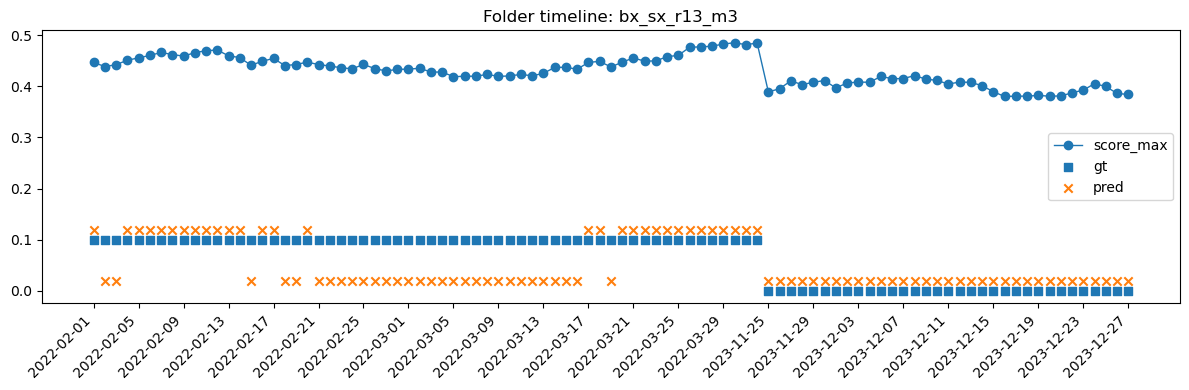

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CSV_FOLDER_DAY = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/occ_isoforest_per_folder_per_day.csv"
df = pd.read_csv(CSV_FOLDER_DAY)

# 특정 폴더만 보고 싶으면 필터
target_group = "bx_sx_r13_m3"
df_g = df[df["group_id"] == target_group].copy()

cm = confusion_matrix(df_g["gt"].values, df_g["pred_anomaly"].values)
print("Confusion:\n", cm)

# 날짜별 pred/gt 비교(간단)
try:
    df_g["date_dt"] = pd.to_datetime(df_g["date"])
except Exception:
    df_g["date_dt"] = df_g["date"]

df_g = df_g.sort_values("date_dt")
x = np.arange(len(df_g))
plt.figure(figsize=(12, 4))
plt.plot(x, df_g["score_max"].values, marker="o", linewidth=1, label="score_max")
plt.scatter(x, df_g["gt"].values * 0.1, marker="s", label="gt")
plt.scatter(x, df_g["pred_anomaly"].values * 0.1 + 0.02, marker="x", label="pred")
plt.xticks(x[::max(1, len(x)//20)], df_g["date"].values[::max(1, len(x)//20)], rotation=45, ha="right")
plt.title(f"Folder timeline: {target_group}")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture


# =========================================================
# [SECTION 1] CAE Model (네 모델 그대로 + encode() 추가)
# =========================================================
class ConvAutoEncoder(nn.Module):
    """
    - forward(x): reconstruction 반환
    - encode(x): bottleneck feature를 pooling 해서 latent 벡터 반환 (OCC 입력)
    """
    def __init__(self, base_ch=32):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]

        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)
        return out

    @torch.no_grad()
    def encode(self, x):
        """
        OCC에 넣을 latent vector 생성.
        - bottleneck feature를 Global Average Pooling -> (B, C)
        """
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)          # (B, C, H', W')
        z = b.mean(dim=(2, 3))           # (B, C)
        return z


# =========================================================
# [SECTION 2] Dataset (경로까지 반환: 네 데이터셋 그대로)
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Loss / Subset
# =========================================================
def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def gradient_loss(pred, target):
    dy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy_tgt  = target[:, :, 1:, :] - target[:, :, :-1, :]
    dx_tgt  = target[:, :, :, 1:] - target[:, :, :, :-1]
    return (dx_pred - dx_tgt).abs().mean() + (dy_pred - dy_tgt).abs().mean()


# =========================================================
# [SECTION 4] 경로 파싱: set/label/battery/module/date 뽑기
# =========================================================
def parse_path_meta(path: str) -> dict:
    """
    예시 경로:
      /.../val/abnormal/2.A.R7M17C6/bx_sx_r13_m3/2022-02-01.png

    우리가 뽑을 것:
      split: val or train or test 등
      label: normal/abnormal (없으면 None)
      battery_id: 2.A.R7M17C6
      module_folder: bx_sx_r13_m3
      rack_num: 13
      module_num: 3
      date_start: 2022-02-01
      gt: (abnormal이면 1, normal이면 0, 그 외 None)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    # 기본: 파일명에서 날짜
    stem = os.path.splitext(os.path.basename(p))[0]  # 2022-02-01
    date_start = stem

    # split/label/battery/module folder는 뒤에서 기준으로 안정적으로 뽑음
    # ... / <split> / <label> / <battery> / <module_folder> / <file>
    module_folder = parts[-2] if len(parts) >= 2 else None
    battery_id = parts[-3] if len(parts) >= 3 else None
    label = parts[-4] if len(parts) >= 4 else None
    split = parts[-5] if len(parts) >= 5 else None

    # rack/module 숫자 파싱: r13_m3 형태를 찾음
    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder) if module_folder else None
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    return {
        "split": split,
        "label": label,
        "gt": gt,
        "battery_id": battery_id,
        "module_folder": module_folder,     # bx_sx_r13_m3
        "rack_num": rack_num,               # 13
        "module_num": module_num,           # 3
        "date_start": date_start,
    }


# =========================================================
# [SECTION 5] AE Train (옵션) + best 저장
# =========================================================
def train_ae(
    model, train_loader, normal_loader, abnormal_loader,
    device, num_epoch=30, lr=1e-3, lambda_grad=0.10,
    model_dir="./model", save_every_epoch=True
):
    os.makedirs(model_dir, exist_ok=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()
    lr_sche = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

    best_normal = float("inf")
    best_path = os.path.join(model_dir, "best_ae.pth")

    for epoch in range(num_epoch):
        # ---- Train ----
        model.train()
        running = 0.0
        for x, _p in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            xhat = model(x)

            l1 = criterion(xhat, x)
            g = gradient_loss(xhat, x)
            loss = (1.0 - lambda_grad) * l1 + lambda_grad * g

            loss.backward()
            optimizer.step()
            running += loss.item()

        lr_sche.step()
        print(f"[Epoch {epoch+1}/{num_epoch}] train loss: {running / max(1, len(train_loader)):.6f}")

        # ---- Val normal ----
        model.eval()
        normal_loss = 0.0
        with torch.no_grad():
            for x, _ in normal_loader:
                x = x.to(device)
                xhat = model(x)
                l1 = criterion(xhat, x)
                g = gradient_loss(xhat, x)
                loss = (1.0 - lambda_grad) * l1 + lambda_grad * g
                normal_loss += loss.item() * x.size(0)

        normal_loss /= max(1, len(normal_loader.dataset))
        print(f"[Epoch {epoch+1}] val normal loss: {normal_loss:.6f}")

        # ---- Val abnormal (참고용) ----
        abnormal_loss = 0.0
        with torch.no_grad():
            for x, _ in abnormal_loader:
                x = x.to(device)
                xhat = model(x)
                l1 = criterion(xhat, x)
                g = gradient_loss(xhat, x)
                loss = (1.0 - lambda_grad) * l1 + lambda_grad * g
                abnormal_loss += loss.item() * x.size(0)

        abnormal_loss /= max(1, len(abnormal_loader.dataset))
        print(f"[Epoch {epoch+1}] val abnormal loss: {abnormal_loss:.6f}")

        # ---- Save ----
        if save_every_epoch:
            torch.save(model.state_dict(), os.path.join(model_dir, f"epoch_{epoch+1}.pth"))

        if normal_loss < best_normal:
            best_normal = normal_loss
            torch.save(model.state_dict(), best_path)
            print(f"[BEST] saved: {best_path} (best normal loss={best_normal:.6f})")

    return best_path


# =========================================================
# [SECTION 6] Latent 추출
# =========================================================
@torch.no_grad()
def extract_latent_table(model, loader, device) -> pd.DataFrame:
    """
    loader에서 latent 뽑고, path meta까지 포함한 DataFrame 반환
    """
    model.eval()
    rows = []

    for x, paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()  # (B, latent_dim)

        for i, p in enumerate(paths):
            meta = parse_path_meta(p)
            rows.append({
                "path": p,
                **meta,
                "latent": z[i],  # numpy array
            })

    df = pd.DataFrame(rows)
    return df


# =========================================================
# [SECTION 7] OCC (학습/스코어/threshold)
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        # novelty=True 필수
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        if "random_state" not in params:
            params["random_state"] = seed
        return GaussianMixture(**params)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(model, X, occ_type: str):
    """
    항상 "클수록 이상" 스코어로 통일
    """
    if occ_type == "isoforest":
        return (-model.score_samples(X)).ravel()
    if occ_type == "lof":
        return (-model.decision_function(X)).ravel()
    if occ_type == "gmm":
        return (-model.score_samples(X)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    """
    val normal/abnormal이 있으니 threshold는 F1 max로 선택
    """
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))

        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


# =========================================================
# [SECTION 8] 최종 결과: per-file / per-module-day / per-module / per-battery
# =========================================================
def build_result_tables(df_scored: pd.DataFrame, threshold: float, out_dir: str, prefix: str):
    """
    df_scored: per-file 수준 (path, battery_id, module_folder, rack_num, module_num, date_start, score, gt 등)
    threshold로 pred 만들고,
    - per_file
    - per_module_day (battery+module+date)
    - per_module (battery+module)
    - per_battery
    저장 및 반환
    """
    df = df_scored.copy()
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    os.makedirs(out_dir, exist_ok=True)

    # 1) per-file
    per_file_path = os.path.join(out_dir, f"{prefix}_per_file.csv")
    df.to_csv(per_file_path, index=False)

    # 2) per module per day (실시간 “하루 chunk 1개”면 이게 핵심 결과)
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num", "date_start"]).reset_index(drop=True)

    per_module_day_path = os.path.join(out_dir, f"{prefix}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_path, index=False)

    # 3) per module (어떤 모듈이 이상인지)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num"]).reset_index(drop=True)

    per_module_path = os.path.join(out_dir, f"{prefix}_per_module.csv")
    df_module.to_csv(per_module_path, index=False)

    # 4) per battery (어떤 배터리가 이상인지)
    df_battery = df_module.groupby(
        ["battery_id"],
        as_index=False
    ).agg(
        n_modules=("module_folder", "count"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
    ).sort_values(["pred_anomaly", "abnormal_modules", "score_max"], ascending=[False, False, False]).reset_index(drop=True)

    per_battery_path = os.path.join(out_dir, f"{prefix}_per_battery.csv")
    df_battery.to_csv(per_battery_path, index=False)

    print("Saved:", per_file_path)
    print("Saved:", per_module_day_path)
    print("Saved:", per_module_path)
    print("Saved:", per_battery_path)

    return df, df_module_day, df_module, df_battery


# =========================================================
# [SECTION 9] MAIN
# =========================================================
if __name__ == "__main__":
    # ---------------------------
    # (0) 설정
    # ---------------------------
    SEED = 777
    os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    # 데이터 경로
    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"

    # 저장 경로
    out_dir = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck/OCC"
    os.makedirs(out_dir, exist_ok=True)

    # 학습 파라미터
    TRAIN_AE = False         # False면 best_ae_path를 이미 있는 모델로 지정해서 로드만
    BEST_AE_PATH = os.path.join(out_dir, "best_ae.pth")

    BASE_CH = 48
    NUM_EPOCH = 30
    LR = 1e-3
    LAMBDA_GRAD = 0.10

    BATCH_SIZE = 100
    VAL_BATCH = 64

    USE_SUBSET = False
    SUBSET_SIZE = 64

    USE_VAL_SUBSET = False
    VAL_SUBSET_N = 256
    VAL_SUBSET_A = 256

    # OCC 설정
    OCC_TYPE = "lof"          # "lof" / "gmm"
    OCC_PARAMS = {}                # iForest 예: {"n_estimators":300} / LOF {"n_neighbors":20} / GMM {"n_components":4}
    PREFIX = f"occ_{OCC_TYPE}"

    # threshold 설정 방법
    USE_F1_THRESHOLD = True
    VAL_QUANTILE = 0.995

    transform = ToTensor()

    # ---------------------------
    # (1) dataset / loader
    # ---------------------------
    train_ds = ImgDataset(train, transform)
    valn_ds = ImgDataset(val_normal, transform)
    vala_ds = ImgDataset(val_abnormal, transform)

    if USE_SUBSET:
        train_ds = make_subset(train_ds, SUBSET_SIZE, seed=SEED)
    if USE_VAL_SUBSET:
        valn_ds = make_subset(valn_ds, VAL_SUBSET_N, seed=SEED)
        vala_ds = make_subset(vala_ds, VAL_SUBSET_A, seed=SEED + 1)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    valn_loader  = DataLoader(valn_ds,  batch_size=VAL_BATCH, shuffle=False, num_workers=4, pin_memory=True)
    vala_loader  = DataLoader(vala_ds,  batch_size=VAL_BATCH, shuffle=False, num_workers=4, pin_memory=True)

    print("train images:", len(train_ds))
    print("val normal images:", len(valn_ds))
    print("val abnormal images:", len(vala_ds))

    # ---------------------------
    # (2) AE 학습 or 로드
    # ---------------------------
    model = ConvAutoEncoder(base_ch=BASE_CH).to(device)

    if TRAIN_AE:
        BEST_AE_PATH = train_ae(
            model=model,
            train_loader=train_loader,
            normal_loader=valn_loader,
            abnormal_loader=vala_loader,
            device=device,
            num_epoch=NUM_EPOCH,
            lr=LR,
            lambda_grad=LAMBDA_GRAD,
            model_dir=out_dir,
            save_every_epoch=True,
        )
    BEST_AE_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth"
    # best 로드
    model.load_state_dict(torch.load(BEST_AE_PATH, map_location=device))
    model.to(device).eval()
    print("Loaded AE:", BEST_AE_PATH)

    # ---------------------------
    # (3) latent 추출 (train/val normal/val abnormal)
    # ---------------------------
    # train은 shuffle=False로 latent 뽑기 위해 eval loader 하나 더 생성
    train_eval_loader = DataLoader(train_ds, batch_size=VAL_BATCH, shuffle=False, num_workers=4, pin_memory=True)

    df_tr = extract_latent_table(model, train_eval_loader, device)  # latent 포함
    df_vn = extract_latent_table(model, valn_loader, device)
    df_va = extract_latent_table(model, vala_loader, device)

    # latent를 (N,d) 배열로 모으기
    Z_tr = np.stack(df_tr["latent"].values, axis=0)
    Z_vn = np.stack(df_vn["latent"].values, axis=0)
    Z_va = np.stack(df_va["latent"].values, axis=0)

    # ---------------------------
    # (4) latent scaling (권장)
    # ---------------------------
    scaler = StandardScaler()
    Z_tr_s = scaler.fit_transform(Z_tr)
    Z_vn_s = scaler.transform(Z_vn)
    Z_va_s = scaler.transform(Z_va)

    # ---------------------------
    # (5) OCC 학습
    # ---------------------------
    occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
    occ.fit(Z_tr_s)

    s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
    s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

    # ---------------------------
    # (6) threshold 결정
    # ---------------------------
    if USE_F1_THRESHOLD:
        threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
        print(f"[{OCC_TYPE}] threshold={threshold:.6f} (best F1={best_f1:.4f})")
    else:
        threshold = float(np.quantile(s_vn, VAL_QUANTILE))
        print(f"[{OCC_TYPE}] threshold={threshold:.6f} (normal quantile={VAL_QUANTILE})")

    # ---------------------------
    # (7) per-file score 테이블 만들기 (val 전체)
    # ---------------------------
    df_vn_scored = df_vn.drop(columns=["latent"]).copy()
    df_va_scored = df_va.drop(columns=["latent"]).copy()

    df_vn_scored["score"] = s_vn
    df_va_scored["score"] = s_va

    df_scored = pd.concat([df_vn_scored, df_va_scored], axis=0).reset_index(drop=True)

    # ---------------------------
    # (8) 결과 저장: per-file / per-module-day / per-module / per-battery
    # ---------------------------
    df_file, df_module_day, df_module, df_battery = build_result_tables(
        df_scored=df_scored,
        threshold=threshold,
        out_dir=out_dir,
        prefix=PREFIX
    )

    # ---------------------------
    # (9) "어떤 배터리가 비정상인지" + "그 배터리의 어떤 모듈이 비정상인지" 출력
    # ---------------------------
    abnormal_batteries = df_battery[df_battery["pred_anomaly"] == 1]["battery_id"].tolist()

    print("\n==============================")
    print("Abnormal batteries (pred=1):")
    print("==============================")
    for b in abnormal_batteries:
        print("-", b)

    print("\n===============================================")
    print("Abnormal modules per abnormal battery (pred=1):")
    print("===============================================")
    for b in abnormal_batteries:
        sub = df_module[(df_module["battery_id"] == b) & (df_module["pred_anomaly"] == 1)]
        if len(sub) == 0:
            print(f"[{b}] abnormal module: (none?)")
            continue

        print(f"\n[{b}] abnormal modules:")
        for _, r in sub.iterrows():
            # module_folder가 bx_sx_r13_m3 형태, rack_num/module_num이 있으면 같이 출력
            print(f"  - {r['module_folder']} (rack={r['rack_num']}, module={r['module_num']}), "
                  f"abnormal_days={int(r['abnormal_days'])}/{int(r['n_days'])}, score_max={r['score_max']:.4f}")

    # (원하면) 특정 배터리의 날짜별 이상 기록까지 보고 싶을 때:
    # ex_battery = abnormal_batteries[0]
    # print(df_module_day[(df_module_day["battery_id"] == ex_battery) & (df_module_day["pred_anomaly"] == 1)]
    #       [["battery_id","module_folder","date_start","score_max","pred_anomaly","gt"]].head(50))


train images: 22968
val normal images: 9537
val abnormal images: 17340
Loaded AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth


/tmp/ipykernel_3221613/3288969360.py:599: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_AE_PATH, map_location=device))


[lof] threshold=-0.256773 (best F1=0.7850)
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck/OCC/occ_lof_per_file.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck/OCC/occ_lof_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck/OCC/occ_lof_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck/OCC/occ_lof_per_battery.csv

Abnormal batteries (pred=1):
- 00454547(0002)
- 2.A.R7M17C6

Abnormal modules per abnormal battery (pred=1):

[00454547(0002)] abnormal modules:
  - bx_sx_r1_m1 (rack=1, module=1), abnormal_days=33/33, score_max=2.4867
  - bx_sx_r1_m2 (rack=1, module=2), abnormal_days=33/33, score_max=2.2273
  - bx_sx_r1_m3 (rack=1, module=3), abnormal_days=33/33, score_max=2.2682
  - bx_sx_r1_m4 (rack=1, module=4), abnormal_days=33/33, score_max=2.3294
  - bx_sx_r1_m5 (rack=1, module=5), abnormal_days=33/33, score_max=2.9823
  - bx_sx_r1_m6 (rack=1, module=6), abnormal_days=33/33, score_max=2.1871
  - bx_sx_r1_m7 

In [ ]:
# =========================================================
# [SECTION 0] Imports
# =========================================================
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor


# =========================================================
# [SECTION 1] Model (너 모델 그대로)
#   + encode()를 추가해서 latent vector를 OCC 입력으로 사용
# =========================================================
class ConvAutoEncoder(nn.Module):
    """
    - forward(): reconstruction
    - encode(): bottleneck feature를 GAP(GlobalAvgPool)해서 latent vector 반환
    """
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        # Encoder blocks
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        # Decoder (Upsample + Conv + Skip)
        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]

        e1 = self.enc1(x)   # 1/2
        e2 = self.enc2(e1)  # 1/4
        e3 = self.enc3(e2)  # 1/8
        e4 = self.enc4(e3)  # 1/16

        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        """
        OCC에 쓸 latent vector:
        bottleneck feature를 (H,W) 평균내서 (B, C)로 만듦
        """
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)              # (B, C, H', W')
        z = b.mean(dim=(2, 3))               # (B, C)
        return z


# =========================================================
# [SECTION 2] Dataset (너 Dataset 그대로: image, path 반환)
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Utils (subset / loss / path parsing)
# =========================================================
def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def gradient_loss(pred, target):
    """
    선명도 개선용 gradient loss
    """
    dy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    dx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy_tgt  = target[:, :, 1:, :] - target[:, :, :-1, :]
    dx_tgt  = target[:, :, :, 1:] - target[:, :, :, :-1]
    return (dx_pred - dx_tgt).abs().mean() + (dy_pred - dy_tgt).abs().mean()


def parse_val_path_meta(path: str) -> dict:
    """
    val 경로 예:
      .../val/abnormal/2.A.R7M17C6/bx_sx_r13_m3/2022-02-01.png

    반환:
      label: normal/abnormal
      gt: 0/1
      battery_id: 2.A.R7M17C6
      module_folder: bx_sx_r13_m3
      rack_num/module_num: r13_m3 파싱
      date_start: 파일 stem (2022-02-01)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    module_folder = parts[-2] if len(parts) >= 2 else None
    battery_id = parts[-3] if len(parts) >= 3 else None
    label = parts[-4] if len(parts) >= 4 else None  # normal/abnormal
    date_start = os.path.splitext(os.path.basename(p))[0]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder) if module_folder else None
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    return {
        "label": label,
        "gt": gt,
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


# =========================================================
# [SECTION 4] Latent Extraction
# =========================================================
@torch.no_grad()
def extract_latents(model, loader, device):
    """
    loader에서 model.encode()로 latent만 뽑아서 (N,d) 반환
    """
    model.eval()
    zs = []
    for x, _paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        zs.append(z)
    if len(zs) == 0:
        return np.zeros((0, 1), dtype=np.float32)
    return np.concatenate(zs, axis=0)


@torch.no_grad()
def extract_scores_table(model, loader, device, scores: np.ndarray) -> pd.DataFrame:
    """
    loader의 path 순서와 scores 순서가 동일하다는 가정으로
    per-file 결과 테이블을 만든다.
    """
    rows = []
    idx = 0
    for _x, paths in loader:
        b = len(paths)
        for i in range(b):
            p = paths[i]
            meta = parse_val_path_meta(p)
            rows.append({
                "date": meta["date_start"],
                "path": p,
                "score": float(scores[idx + i]),
                "gt": int(meta["gt"]) if meta["gt"] is not None else None,
                "battery_id": meta["battery_id"],
                "module_folder": meta["module_folder"],
                "rack_num": meta["rack_num"],
                "module_num": meta["module_num"],
                "label": meta["label"],
            })
        idx += b
    return pd.DataFrame(rows)


# =========================================================
# [SECTION 5] OCC (fit / score / threshold)
# =========================================================
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture


def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}
    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)
    if occ_type == "lof":
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)  # novelty=True 필수
    if occ_type == "gmm":
        if "random_state" not in params:
            params["random_state"] = seed
        return GaussianMixture(**params)
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(occ_model, X_scaled, occ_type: str):
    """
    점수는 '클수록 이상'으로 통일
    """
    if occ_type == "isoforest":
        return (-occ_model.score_samples(X_scaled)).ravel()
    if occ_type == "lof":
        return (-occ_model.decision_function(X_scaled)).ravel()
    if occ_type == "gmm":
        return (-occ_model.score_samples(X_scaled)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    """
    val normal/abnormal이 있으므로 F1 최대 threshold 선택
    """
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))

        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


# =========================================================
# [SECTION 7] Save artifacts for TEST (AE + scaler + occ + threshold)
# =========================================================
def save_artifacts(out_dir, ae_model, scaler, occ_model, threshold):
    os.makedirs(out_dir, exist_ok=True)

    # best_ae.pth는 이미 train_ae에서 저장되지만,
    # 여기서는 "현재 model state"를 best로 확실히 보장하고 싶으면 다시 저장 가능
    torch.save(ae_model.state_dict(), os.path.join(out_dir, "best_ae.pth"))

    joblib.dump(scaler, os.path.join(out_dir, "latent_scaler.joblib"))
    joblib.dump(occ_model, os.path.join(out_dir, "occ_model.joblib"))
    joblib.dump(float(threshold), os.path.join(out_dir, "threshold.joblib"))

    print("\n=== Saved artifacts for TEST ===")
    print("AE         :", os.path.join(out_dir, "best_ae.pth"))
    print("Scaler     :", os.path.join(out_dir, "latent_scaler.joblib"))
    print("OCC model  :", os.path.join(out_dir, "occ_model.joblib"))
    print("Threshold  :", os.path.join(out_dir, "threshold.joblib"))


# =========================================================
# [SECTION 8] Main (네 전체 코드 + OCC 저장까지)
# =========================================================
if __name__ == "__main__":
    # ---- 설정: 여기만 바꾸면 됨 ----
    USE_SUBSET = False
    SUBSET_SIZE = 32

    USE_VAL_SUBSET = True
    VAL_SUBSET_SIZE_NORMAL = 64
    VAL_SUBSET_SIZE_ABNORMAL = 64

    BATCH_SIZE = 100
    VAL_BATCH_SIZE = 64
    NUM_EPOCH = 30
    LR = 0.001
    SEED = 777

    LAMBDA_GRAD = 0.10
    BASE_CH = 48

    # OCC 설정
    OCC_TYPE = "isoforest"      # "lof" / "gmm"
    OCC_PARAMS = {}             # 예: iForest {"n_estimators":300}, LOF {"n_neighbors":20}, GMM {"n_components":4}

    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    model_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    os.makedirs(model_path, exist_ok=True)

    # (선택) 특정 GPU 고정
    os.environ["CUDA_VISIBLE_DEVICES"] = "1"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    transform = ToTensor()

    # ---- dataset 로드 ----
    train_folder = ImgDataset(root_dir=train, transform=transform)
    normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
    abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

    print("train images:", len(train_folder))
    print("normal images:", len(normal_folder))
    print("abnormal images:", len(abnormal_folder))
    if len(train_folder) > 0:
        print("train example path:", train_folder[0][1])

    # ---- Subset 적용 (train) ----
    if USE_SUBSET:
        train_dataset = make_subset(train_folder, SUBSET_SIZE, seed=SEED)
        print(f"[Train Subset ON] train subset size = {len(train_dataset)}")
    else:
        train_dataset = train_folder
        print(f"[Train Subset OFF] train full size = {len(train_dataset)}")

    # ---- Subset 적용 (val) ----
    if USE_VAL_SUBSET:
        normal_dataset = make_subset(normal_folder, VAL_SUBSET_SIZE_NORMAL, seed=SEED)
        abnormal_dataset = make_subset(abnormal_folder, VAL_SUBSET_SIZE_ABNORMAL, seed=SEED + 1)
        print(f"[Val Subset ON] normal subset size = {len(normal_dataset)}")
        print(f"[Val Subset ON] abnormal subset size = {len(abnormal_dataset)}")
    else:
        normal_dataset = normal_folder
        abnormal_dataset = abnormal_folder
        print(f"[Val Subset OFF] normal full size = {len(normal_dataset)}")
        print(f"[Val Subset OFF] abnormal full size = {len(abnormal_dataset)}")

    # ---- dataloader ----
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    normal_loader = DataLoader(normal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    abnormal_loader = DataLoader(abnormal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    # ---- model ----
    model = ConvAutoEncoder(base_ch=BASE_CH).to(device)

    # =====================================================
    # (1) AE load
    # =====================================================

    best_ae_path = '/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth'
    model.load_state_dict(torch.load(best_ae_path, map_location=device))
    model.to(device).eval()
    print("\nLoaded best AE:", best_ae_path)

    # =====================================================
    # (2) OCC 학습 준비: latent 추출용 loader (shuffle=False)
    # =====================================================
    train_eval_loader = DataLoader(train_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    Z_tr = extract_latents(model, train_eval_loader, device)
    Z_vn = extract_latents(model, normal_loader, device)
    Z_va = extract_latents(model, abnormal_loader, device)

    print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

    # =====================================================
    # (3) latent scaling + OCC fit
    # =====================================================
    scaler = StandardScaler()
    Z_tr_s = scaler.fit_transform(Z_tr)
    Z_vn_s = scaler.transform(Z_vn)
    Z_va_s = scaler.transform(Z_va)

    occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
    occ.fit(Z_tr_s)

    s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
    s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

    # =====================================================
    # (4) threshold 결정 (F1 최대로)
    # =====================================================
    threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
    print(f"\n[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")

    # =====================================================
    # (5) 아티팩트 저장 (TEST에서 그대로 로드해서 사용)
    # =====================================================
    save_artifacts(model_path, model, scaler, occ, threshold)

    # =====================================================
    # (6) (선택) val 결과 CSV 저장 (디버깅/시각화용)
    #     - 이전에 만들었던 occ_isoforest_per_file.csv 형태로 저장
    # =====================================================
    # loader 순서대로 score를 붙여서 per-file 테이블 만들기
    df_vn = extract_scores_table(model, normal_loader, device, s_vn)
    df_va = extract_scores_table(model, abnormal_loader, device, s_va)
    df_val = pd.concat([df_vn, df_va], axis=0).reset_index(drop=True)

    df_val["pred_anomaly"] = (df_val["score"] >= threshold).astype(int)

    out_csv = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
    df_val.to_csv(out_csv, index=False)
    print("\nSaved val per-file csv:", out_csv)


train images: 22968
normal images: 9537
abnormal images: 17340
train example path: /root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train/00321804(0002)/bx_sx_r10_m1/2023-11-25.png
[Train Subset OFF] train full size = 22968
[Val Subset ON] normal subset size = 64
[Val Subset ON] abnormal subset size = 64

Loaded best AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth


/tmp/ipykernel_3221613/1766880823.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ae_path, map_location=device))


latent shapes: (22968, 384) (64, 384) (64, 384)

[isoforest] threshold=0.559355 (val best F1=0.9508)

=== Saved artifacts for TEST ===
AE         : /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck_OCC/best_ae.pth
Scaler     : /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck_OCC/latent_scaler.joblib
OCC model  : /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck_OCC/occ_model.joblib
Threshold  : /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck_OCC/threshold.joblib

Saved val per-file csv: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck_OCC/occ_isoforest_per_file.csv


In [9]:
# =========================================================
# [TEST SECTION] 저장된 AE + scaler + OCC + threshold로 test 평가
# =========================================================
import joblib
import pandas as pd
import numpy as np
import os
import re
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor


def parse_test_path_meta(path: str) -> dict:
    """
    test 경로가
      .../test/<battery_id>/<module_folder>/<date>.png
    또는
      .../test/(normal|abnormal)/<battery_id>/<module_folder>/<date>.png
    처럼 되어 있어도 '뒤에서' 뽑아내게 만들어 둠.
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # 만약 test가 test/abnormal/battery/module/date.png 구조라면
    # battery_id가 abnormal이 되는 문제를 피하기 위해 한 번 보정
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def run_test_inference(
    test_root: str,
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    out_dir: str,
    batch_size: int = 64
):
    os.makedirs(out_dir, exist_ok=True)

    # (1) 학습 때 저장한 아티팩트 로드
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # (2) AE 로드 (학습 때와 동일한 모델 구조여야 함)
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # (3) test dataset / loader
    test_ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # (4) test latent → score
    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()        # (B,d)
            z_s = scaler.transform(z)                         # (B,d)

            # 점수는 "클수록 이상"으로 통일
            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    # (5) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # (6) 배터리/모듈 관점 집계 (너가 원하는 핵심)
    # - 모듈+날짜 단위(실시간 chunk 단위)
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num", "date_start"]).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # - 모듈 단위(어떤 모듈이 이상인가)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num"]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # - 배터리 단위(어떤 배터리가 이상인가)
    df_battery = df_module.groupby(
        ["battery_id"],
        as_index=False
    ).agg(
        n_modules=("module_folder", "count"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["pred_anomaly", "abnormal_modules", "score_max"], ascending=[False, False, False]).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    # (7) 콘솔 출력: 이상 배터리/모듈
    abnormal_batteries = df_battery[df_battery["pred_anomaly"] == 1]["battery_id"].tolist()

    print("\n=== Abnormal batteries (pred=1) ===")
    for b in abnormal_batteries:
        print("-", b)

    print("\n=== Abnormal modules per abnormal battery ===")
    for b in abnormal_batteries:
        sub = df_module[(df_module["battery_id"] == b) & (df_module["pred_anomaly"] == 1)]
        print(f"\n[{b}]")
        for _, r in sub.iterrows():
            print(f"  - {r['module_folder']} (rack={r['rack_num']}, module={r['module_num']}) "
                  f"| abnormal_days={int(r['abnormal_days'])}/{int(r['n_days'])} | score_max={r['score_max']:.4f}")

    return df, df_module_day, df_module, df_battery


# =========================
# 사용 예시 (여기만 바꿔서 실행)
# =========================
if __name__ == "__main__":
    TEST_ROOT = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/test/normal"  # test 폴더만 지정
    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/)"

    OCC_TYPE = "isoforest"   # 학습 때와 동일하게
    BASE_CH = 48             # 학습 때와 동일하게

    device = "cuda" if torch.cuda.is_available() else "cpu"

    run_test_inference(
        test_root=TEST_ROOT,
        model_path=MODEL_PATH,
        base_ch=BASE_CH,
        occ_type=OCC_TYPE,
        device=device,
        out_dir=OUT_DIR,
        batch_size=64
    )


/tmp/ipykernel_3221613/1089480613.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)/test_isoforest_per_file.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)/test_isoforest_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)/test_isoforest_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)/test_isoforest_per_battery.csv

=== Abnormal batteries (pred=1) ===
- 00329601(0002)

=== Abnormal modules per abnormal battery ===

[00329601(0002)]
  - bx_sx_r1_m2 (rack=1, module=2) | abnormal_days=29/34 | score_max=0.6119
  - bx_sx_r1_m4 (rack=1, module=4) | abnormal_days=28/34 | score_max=0.6083
  - bx_sx_r1_m6 (rack=1, module=6) | abnormal_days=28/34 | score_max=0.6091
  - bx_sx_r1_m8 (rack=1, module=8) | abnormal_days=31/34 | score_max=0.6140
  - bx_sx_r1_m10 (rack=1, module=10) | abnormal_days=27/34 | score_max=0.6084
  - bx_sx_r1_m12 (rack=1, module=12) | abnormal_days=27/34 | score_max=0.6127
  - bx_sx_

In [10]:
# =========================================================
# [TEST SECTION] 저장된 AE + scaler + OCC + threshold로 test 평가
# =========================================================
import joblib
import pandas as pd
import numpy as np
import os
import re
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor


def parse_test_path_meta(path: str) -> dict:
    """
    test 경로가
      .../test/<battery_id>/<module_folder>/<date>.png
    또는
      .../test/(normal|abnormal)/<battery_id>/<module_folder>/<date>.png
    처럼 되어 있어도 '뒤에서' 뽑아내게 만들어 둠.
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # 만약 test가 test/abnormal/battery/module/date.png 구조라면
    # battery_id가 abnormal이 되는 문제를 피하기 위해 한 번 보정
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def run_test_inference(
    test_root: str,
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    out_dir: str,
    batch_size: int = 64
):
    os.makedirs(out_dir, exist_ok=True)

    # (1) 학습 때 저장한 아티팩트 로드
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # (2) AE 로드 (학습 때와 동일한 모델 구조여야 함)
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # (3) test dataset / loader
    test_ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # (4) test latent → score
    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()        # (B,d)
            z_s = scaler.transform(z)                         # (B,d)

            # 점수는 "클수록 이상"으로 통일
            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    # (5) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # (6) 배터리/모듈 관점 집계 (너가 원하는 핵심)
    # - 모듈+날짜 단위(실시간 chunk 단위)
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num", "date_start"]).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # - 모듈 단위(어떤 모듈이 이상인가)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num"]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # - 배터리 단위(어떤 배터리가 이상인가)
    df_battery = df_module.groupby(
        ["battery_id"],
        as_index=False
    ).agg(
        n_modules=("module_folder", "count"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["pred_anomaly", "abnormal_modules", "score_max"], ascending=[False, False, False]).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    # (7) 콘솔 출력: 이상 배터리/모듈
    abnormal_batteries = df_battery[df_battery["pred_anomaly"] == 1]["battery_id"].tolist()

    print("\n=== Abnormal batteries (pred=1) ===")
    for b in abnormal_batteries:
        print("-", b)

    print("\n=== Abnormal modules per abnormal battery ===")
    for b in abnormal_batteries:
        sub = df_module[(df_module["battery_id"] == b) & (df_module["pred_anomaly"] == 1)]
        print(f"\n[{b}]")
        for _, r in sub.iterrows():
            print(f"  - {r['module_folder']} (rack={r['rack_num']}, module={r['module_num']}) "
                  f"| abnormal_days={int(r['abnormal_days'])}/{int(r['n_days'])} | score_max={r['score_max']:.4f}")

    return df, df_module_day, df_module, df_battery


# =========================
# 사용 예시 (여기만 바꿔서 실행)
# =========================
if __name__ == "__main__":
    TEST_ROOT = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/test/abnormal"  # test 폴더만 지정
    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)"

    OCC_TYPE = "isoforest"   # 학습 때와 동일하게
    BASE_CH = 48             # 학습 때와 동일하게

    device = "cuda" if torch.cuda.is_available() else "cpu"

    run_test_inference(
        test_root=TEST_ROOT,
        model_path=MODEL_PATH,
        base_ch=BASE_CH,
        occ_type=OCC_TYPE,
        device=device,
        out_dir=OUT_DIR,
        batch_size=64
    )


/tmp/ipykernel_3221613/1031981189.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)/test_isoforest_per_file.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)/test_isoforest_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)/test_isoforest_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)/test_isoforest_per_battery.csv

=== Abnormal batteries (pred=1) ===
- 3.A.R5M7C11

=== Abnormal modules per abnormal battery ===

[3.A.R5M7C11]
  - bx_sx_r1_m1 (rack=1, module=1) | abnormal_days=38/153 | score_max=0.6229
  - bx_sx_r1_m2 (rack=1, module=2) | abnormal_days=42/153 | score_max=0.6254
  - bx_sx_r1_m3 (rack=1, module=3) | abnormal_days=73/153 | score_max=0.6204
  - bx_sx_r1_m4 (rack=1, module=4) | abnormal_days=99/153 | score_max=0.6281
  - bx_sx_r1_m5 (rack=1, module=5) | abnormal_days=45/153 | score_max=0.6276
  - bx_sx_r1_m6 (rack=1, module=6) | abnormal_days=34/153 | score_max=0.6262
  - bx

In [11]:
# =========================================================
# [TEST SECTION] 저장된 AE + scaler + OCC + threshold로 test 평가
# =========================================================
import joblib
import pandas as pd
import numpy as np
import os
import re
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor


def parse_test_path_meta(path: str) -> dict:
    """
    test 경로가
      .../test/<battery_id>/<module_folder>/<date>.png
    또는
      .../test/(normal|abnormal)/<battery_id>/<module_folder>/<date>.png
    처럼 되어 있어도 '뒤에서' 뽑아내게 만들어 둠.
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # test/abnormal/battery/module/date.png 구조 대응
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def run_test_inference(
    test_root: str,
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    out_dir: str,
    batch_size: int = 64
):
    os.makedirs(out_dir, exist_ok=True)

    # (1) 학습 때 저장한 아티팩트 로드
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # (2) AE 로드 (학습 때와 동일한 모델 구조여야 함)
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # (3) test dataset / loader
    test_ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # (4) test latent → score (per-file)
    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()        # (B,d)
            z_s = scaler.transform(z)                         # (B,d)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    # (5) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # =====================================================
    # (6) 모듈/배터리 집계
    # =====================================================

    # (6-1) 모듈+날짜 단위 (실시간 chunk 단위)
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num", "date_start"]).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # (6-2) ✅ 모듈 단위 (너가 원하는 결과)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),   # 하루라도 이상이면 모듈 이상
    ).sort_values(["pred_anomaly", "score_max"], ascending=[False, False]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # (6-3) (선택) 배터리 단위
    # - n_modules는 "모듈 개수"니까 count 대신 nunique로 세는 게 정확함
    df_battery = df_module.groupby(["battery_id"], as_index=False).agg(
        n_modules=("module_folder", "nunique"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["pred_anomaly", "abnormal_modules", "score_max"], ascending=[False, False, False]).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    # =====================================================
    # (7) ✅ 콘솔 출력: "모듈별 이상"만 보고 싶을 때
    # =====================================================
    abnormal_modules = df_module[df_module["pred_anomaly"] == 1].copy()

    print("\n=== Abnormal modules (pred=1) ===")
    if len(abnormal_modules) == 0:
        print("(none)")
    else:
        # 배터리별로 보기 좋게 출력
        for b, sub in abnormal_modules.groupby("battery_id"):
            print(f"\n[{b}]")
            sub = sub.sort_values(["score_max"], ascending=False)
            for _, r in sub.iterrows():
                print(f"  - {r['module_folder']} (rack={r['rack_num']}, module={r['module_num']}) "
                      f"| abnormal_days={int(r['abnormal_days'])}/{int(r['n_days'])} | score_max={r['score_max']:.4f}")

    # (선택) 이상 모듈만 따로 CSV 저장
    abnormal_module_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_modules.to_csv(abnormal_module_csv, index=False)
    print("Saved:", abnormal_module_csv)

    return df, df_module_day, df_module, df_battery


# =========================
# 사용 예시 (여기만 바꿔서 실행)
# =========================
if __name__ == "__main__":
    TEST_ROOT = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/test/normal"
    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)_module"

    OCC_TYPE = "isoforest"
    BASE_CH = 48

    device = "cuda" if torch.cuda.is_available() else "cpu"

    run_test_inference(
        test_root=TEST_ROOT,
        model_path=MODEL_PATH,
        base_ch=BASE_CH,
        occ_type=OCC_TYPE,
        device=device,
        out_dir=OUT_DIR,
        batch_size=64
    )


/tmp/ipykernel_3221613/1154667053.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)_module/test_isoforest_per_file.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)_module/test_isoforest_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)_module/test_isoforest_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/normal)_module/test_isoforest_per_battery.csv

=== Abnormal modules (pred=1) ===

[00329601(0002)]
  - bx_sx_r10_m5 (rack=10, module=5) | abnormal_days=27/34 | score_max=0.6368
  - bx_sx_r2_m1 (rack=2, module=1) | abnormal_days=27/34 | score_max=0.6287
  - bx_sx_r2_m3 (rack=2, module=3) | abnormal_days=27/34 | score_max=0.6271
  - bx_sx_r2_m5 (rack=2, module=5) | abnormal_days=27/34 | score_max=0.6234
  - bx_sx_r7_m8 (rack=7, module=8) | abnormal_days=32/34 | score_max=0.6234
  - bx_sx_r9_m2 (rack=9, module=2) | abnormal_days=27/34 | score_max=0.6230
  - bx_sx_r13_m4 (rack=13, module=4) | abnormal_da

In [12]:
# =========================================================
# [TEST SECTION] 저장된 AE + scaler + OCC + threshold로 test 평가
# =========================================================
import joblib
import pandas as pd
import numpy as np
import os
import re
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor


def parse_test_path_meta(path: str) -> dict:
    """
    test 경로가
      .../test/<battery_id>/<module_folder>/<date>.png
    또는
      .../test/(normal|abnormal)/<battery_id>/<module_folder>/<date>.png
    처럼 되어 있어도 '뒤에서' 뽑아내게 만들어 둠.
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # test/abnormal/battery/module/date.png 구조 대응
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def run_test_inference(
    test_root: str,
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    out_dir: str,
    batch_size: int = 64
):
    os.makedirs(out_dir, exist_ok=True)

    # (1) 학습 때 저장한 아티팩트 로드
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # (2) AE 로드 (학습 때와 동일한 모델 구조여야 함)
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # (3) test dataset / loader
    test_ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # (4) test latent → score (per-file)
    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()        # (B,d)
            z_s = scaler.transform(z)                         # (B,d)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    # (5) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # =====================================================
    # (6) 모듈/배터리 집계
    # =====================================================

    # (6-1) 모듈+날짜 단위 (실시간 chunk 단위)
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["battery_id", "rack_num", "module_num", "date_start"]).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # (6-2) ✅ 모듈 단위 (너가 원하는 결과)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),   # 하루라도 이상이면 모듈 이상
    ).sort_values(["pred_anomaly", "score_max"], ascending=[False, False]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # (6-3) (선택) 배터리 단위
    # - n_modules는 "모듈 개수"니까 count 대신 nunique로 세는 게 정확함
    df_battery = df_module.groupby(["battery_id"], as_index=False).agg(
        n_modules=("module_folder", "nunique"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    ).sort_values(["pred_anomaly", "abnormal_modules", "score_max"], ascending=[False, False, False]).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    # =====================================================
    # (7) ✅ 콘솔 출력: "모듈별 이상"만 보고 싶을 때
    # =====================================================
    abnormal_modules = df_module[df_module["pred_anomaly"] == 1].copy()

    print("\n=== Abnormal modules (pred=1) ===")
    if len(abnormal_modules) == 0:
        print("(none)")
    else:
        # 배터리별로 보기 좋게 출력
        for b, sub in abnormal_modules.groupby("battery_id"):
            print(f"\n[{b}]")
            sub = sub.sort_values(["score_max"], ascending=False)
            for _, r in sub.iterrows():
                print(f"  - {r['module_folder']} (rack={r['rack_num']}, module={r['module_num']}) "
                      f"| abnormal_days={int(r['abnormal_days'])}/{int(r['n_days'])} | score_max={r['score_max']:.4f}")

    # (선택) 이상 모듈만 따로 CSV 저장
    abnormal_module_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_modules.to_csv(abnormal_module_csv, index=False)
    print("Saved:", abnormal_module_csv)

    return df, df_module_day, df_module, df_battery


# =========================
# 사용 예시 (여기만 바꿔서 실행)
# =========================
if __name__ == "__main__":
    TEST_ROOT = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/test/abnormal"
    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)_module"

    OCC_TYPE = "isoforest"
    BASE_CH = 48

    device = "cuda" if torch.cuda.is_available() else "cpu"

    run_test_inference(
        test_root=TEST_ROOT,
        model_path=MODEL_PATH,
        base_ch=BASE_CH,
        occ_type=OCC_TYPE,
        device=device,
        out_dir=OUT_DIR,
        batch_size=64
    )


/tmp/ipykernel_3221613/892511467.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)_module/test_isoforest_per_file.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)_module/test_isoforest_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)_module/test_isoforest_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results(blindX/abnormal)_module/test_isoforest_per_battery.csv

=== Abnormal modules (pred=1) ===

[3.A.R5M7C11]
  - bx_sx_r2_m6 (rack=2, module=6) | abnormal_days=43/153 | score_max=0.6296
  - bx_sx_r4_m4 (rack=4, module=4) | abnormal_days=50/153 | score_max=0.6293
  - bx_sx_r4_m13 (rack=4, module=13) | abnormal_days=43/153 | score_max=0.6288
  - bx_sx_r2_m11 (rack=2, module=11) | abnormal_days=39/153 | score_max=0.6285
  - bx_sx_r3_m4 (rack=3, module=4) | abnormal_days=60/153 | score_max=0.6284
  - bx_sx_r5_m11 (rack=5, module=11) | abnormal_days=63/153 | score_max=0.6284
  - bx_sx_r5_m13 (rack=5, module=13

In [13]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def parse_test_path_meta(path: str) -> dict:
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # test/abnormal/battery/module/date.png 구조 대응
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def infer_one_folder(
    test_root: str,
    gt_label: int,              # normal=0, abnormal=1
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    batch_size: int = 64,
) -> pd.DataFrame:
    # artifacts
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # AE
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # dataset/loader
    ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    rows = []
    with torch.no_grad():
        for x, paths in loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()
            z_s = scaler.transform(z)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    "gt": int(gt_label),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)
    return df


def evaluate_test_per_module(
    test_normal_root: str,
    test_abnormal_root: str,
    model_path: str,
    out_dir: str,
    base_ch: int = 48,
    occ_type: str = "isoforest",
    batch_size: int = 64,
):
    os.makedirs(out_dir, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1) normal/abnormal 각각 inference (per-file)
    df_n = infer_one_folder(
        test_root=test_normal_root, gt_label=0,
        model_path=model_path, base_ch=base_ch, occ_type=occ_type,
        device=device, batch_size=batch_size
    )
    df_a = infer_one_folder(
        test_root=test_abnormal_root, gt_label=1,
        model_path=model_path, base_ch=base_ch, occ_type=occ_type,
        device=device, batch_size=batch_size
    )

    df = pd.concat([df_n, df_a], axis=0).reset_index(drop=True)

    # (선택) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file_with_gt.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # 2) 모듈+날짜 단위로 먼저 묶어서(파일 여러장/하루 대비) 안정화
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
    )

    # 3) ✅ per-module 집계 (너가 원하는 평가 단위)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),  # 하루라도 이상이면 모듈 이상
        gt=("gt", "max"),                      # gt도 하루라도 abnormal이면 모듈 gt=1
    ).sort_values(["battery_id", "rack_num", "module_num"]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_with_gt.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # 4) per-module metrics
    y_true = df_module["gt"].values
    y_pred = df_module["pred_anomaly"].values

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)  # [[TN,FP],[FN,TP]]

    print("\n=== Test Metrics (per-module) ===")
    print("Confusion Matrix [[TN,FP],[FN,TP]]:\n", cm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

    return df_module, {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}


# =========================
# 사용 예시
# =========================
if __name__ == "__main__":
    TEST_NORMAL = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal"
    TEST_ABNORMAL = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/abnormal"

    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/test_results_eval_per_module"

    evaluate_test_per_module(
        test_normal_root=TEST_NORMAL,
        test_abnormal_root=TEST_ABNORMAL,
        model_path=MODEL_PATH,
        out_dir=OUT_DIR,
        base_ch=48,
        occ_type="isoforest",
        batch_size=64
    )


/tmp/ipykernel_3221613/473423031.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))
/tmp/ipykernel_3221613/

Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results_eval_per_module/test_isoforest_per_file_with_gt.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results_eval_per_module/test_isoforest_per_module_with_gt.csv

=== Test Metrics (per-module) ===
Confusion Matrix [[TN,FP],[FN,TP]]:
 [[2 1]
 [0 1]]
Accuracy : 0.7500
Precision: 0.5000
Recall   : 1.0000
F1       : 0.6667


In [ ]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def parse_test_path_meta(path: str) -> dict:
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # test/abnormal/battery/module/date.png 구조 대응
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def infer_one_folder(
    test_root: str,
    gt_label: int,              # normal=0, abnormal=1
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    batch_size: int = 64,
) -> pd.DataFrame:
    # artifacts
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # AE
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # dataset/loader
    ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    rows = []
    with torch.no_grad():
        for x, paths in loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()
            z_s = scaler.transform(z)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    "gt": int(gt_label),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)
    return df


def evaluate_test_per_module(
    test_normal_root: str,
    test_abnormal_root: str,
    model_path: str,
    out_dir: str,
    base_ch: int = 48,
    occ_type: str = "isoforest",
    batch_size: int = 64,
):
    os.makedirs(out_dir, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1) normal/abnormal 각각 inference (per-file)
    df_n = infer_one_folder(
        test_root=test_normal_root, gt_label=0,
        model_path=model_path, base_ch=base_ch, occ_type=occ_type,
        device=device, batch_size=batch_size
    )
    df_a = infer_one_folder(
        test_root=test_abnormal_root, gt_label=1,
        model_path=model_path, base_ch=base_ch, occ_type=occ_type,
        device=device, batch_size=batch_size
    )

    df = pd.concat([df_n, df_a], axis=0).reset_index(drop=True)

    # (선택) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file_with_gt.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # 2) 모듈+날짜 단위로 먼저 묶어서(파일 여러장/하루 대비) 안정화
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
    )

    # 3) ✅ per-module 집계 (너가 원하는 평가 단위)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),  # 하루라도 이상이면 모듈 이상
        gt=("gt", "max"),                      # gt도 하루라도 abnormal이면 모듈 gt=1
    ).sort_values(["battery_id", "rack_num", "module_num"]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_with_gt.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # 4) per-module metrics
    y_true = df_module["gt"].values
    y_pred = df_module["pred_anomaly"].values

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)  # [[TN,FP],[FN,TP]]

    print("\n=== Test Metrics (per-module) ===")
    print("Confusion Matrix [[TN,FP],[FN,TP]]:\n", cm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

    return df_module, {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}


# =========================
# 사용 예시
# =========================
if __name__ == "__main__":
    TEST_NORMAL = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal"
    TEST_ABNORMAL = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/abnormal"

    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/test_results_eval_per_module"

    evaluate_test_per_module(
        test_normal_root=TEST_NORMAL,
        test_abnormal_root=TEST_ABNORMAL,
        model_path=MODEL_PATH,
        out_dir=OUT_DIR,
        base_ch=48,
        occ_type="isoforest",
        batch_size=64
    )


/tmp/ipykernel_3221613/473423031.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))
/tmp/ipykernel_3221613/

Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results_eval_per_module/test_isoforest_per_file_with_gt.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results_eval_per_module/test_isoforest_per_module_with_gt.csv

=== Test Metrics (per-module) ===
Confusion Matrix [[TN,FP],[FN,TP]]:
 [[2 1]
 [0 1]]
Accuracy : 0.7500
Precision: 0.5000
Recall   : 1.0000
F1       : 0.6667


In [21]:
# =========================================================
# [TEST PER-MODULE EVAL] float/NaN 안전 처리 포함
# =========================================================
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def parse_test_path_meta(path: str) -> dict:
    """
    test 경로에서 battery/module/date, rack/module 번호 추출
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]

    # test/abnormal/battery/module/date.png 구조 대응
    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def infer_one_folder(
    test_root: str,
    gt_label: int,
    model_path: str,
    base_ch: int,
    occ_type: str,
    device: str,
    batch_size: int = 64,
) -> pd.DataFrame:
    """
    normal/abnormal 폴더 각각 inference해서 per-file df 반환
    (gt 포함)
    """
    # artifacts
    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    # AE
    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    # dataset/loader
    ds = ImgDataset(root_dir=test_root, transform=ToTensor())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    rows = []
    with torch.no_grad():
        for x, paths in loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy()
            z_s = scaler.transform(z)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({
                    "path": p,
                    "score": float(scores[i]),
                    "gt": int(gt_label),
                    **meta
                })

    df = pd.DataFrame(rows)
    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)
    return df


def normalize_module_index_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    ✅ 핵심: rack_num/module_num 타입 섞임(float/int/str/NaN) 정리
    - 숫자로 변환 후
    - pandas nullable Int64로 변환 (NaN 허용)
    - groupby에서 누락 방지용으로 NaN을 -1로 채운 key도 만들어줌
    """
    df = df.copy()

    # 숫자로 강제 변환 (문자열/None/NaN 섞여도 처리)
    df["rack_num"] = pd.to_numeric(df["rack_num"], errors="coerce")
    df["module_num"] = pd.to_numeric(df["module_num"], errors="coerce")

    # float(1.0) -> Int64(1) 로 변환 (NaN 허용)
    df["rack_num"] = df["rack_num"].round().astype("Int64")
    df["module_num"] = df["module_num"].round().astype("Int64")

    # groupby key용: NaN이면 -1로 채워서 그룹 누락 방지
    df["rack_num_key"] = df["rack_num"].fillna(-1).astype(int)
    df["module_num_key"] = df["module_num"].fillna(-1).astype(int)

    return df


def evaluate_test_per_module(
    test_normal_root: str,
    test_abnormal_root: str,
    model_path: str,
    out_dir: str,
    base_ch: int = 48,
    occ_type: str = "isoforest",
    batch_size: int = 64,
):
    os.makedirs(out_dir, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1) per-file inference (normal/abnormal)
    df_n = infer_one_folder(test_normal_root, 0, model_path, base_ch, occ_type, device, batch_size)
    df_a = infer_one_folder(test_abnormal_root, 1, model_path, base_ch, occ_type, device, batch_size)
    df = pd.concat([df_n, df_a], axis=0).reset_index(drop=True)

    # 2) ✅ rack/module 컬럼 정규화 (float/NaN 대응)
    df = normalize_module_index_columns(df)

    # (선택) per-file 저장
    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file_with_gt.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    # 3) 모듈+날짜 단위 집계
    # - key 컬럼은 rack_num_key/module_num_key 사용 (NaN이면 -1)
    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num_key", "module_num_key", "date_start"],
        as_index=False
    ).agg(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
        # 보기용 원본 값도 같이 남김 (nullable Int64)
        rack_num=("rack_num", "first"),
        module_num=("module_num", "first"),
    ).sort_values(["battery_id", "module_folder", "date_start"]).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day_with_gt.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # 4) ✅ per-module 집계 (최종 평가 단위)
    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num_key", "module_num_key"],
        as_index=False
    ).agg(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
        gt=("gt", "max"),
        rack_num=("rack_num", "first"),
        module_num=("module_num", "first"),
    ).sort_values(["battery_id", "module_folder"]).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_with_gt.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # 5) per-module metrics
    y_true = df_module["gt"].values
    y_pred = df_module["pred_anomaly"].values

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)  # [[TN,FP],[FN,TP]]

    print("\n=== Test Metrics (per-module) ===")
    print("Confusion Matrix [[TN,FP],[FN,TP]]:\n", cm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

    # 6) (선택) 이상 모듈만 따로 저장
    abnormal_only = df_module[df_module["pred_anomaly"] == 1].copy()
    abnormal_only_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_only.to_csv(abnormal_only_csv, index=False)
    print("Saved:", abnormal_only_csv)

    return df_module, {"acc": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}


# =========================
# 사용 예시
# =========================
if __name__ == "__main__":
    TEST_NORMAL = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal"
    TEST_ABNORMAL = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/abnormal"

    MODEL_PATH = "/root/ssd/yeonseo/ess/OCC_Algorithm/isoforest/Conv_bottleneck_OCC"
    OUT_DIR = "/root/ssd/yeonseo/ess/OCC_Algorithm/isoforest/test_results_eval_per_module"

    evaluate_test_per_module(
        test_normal_root=TEST_NORMAL,
        test_abnormal_root=TEST_ABNORMAL,
        model_path=MODEL_PATH,
        out_dir=OUT_DIR,
        base_ch=48,
        occ_type="isoforest",
        batch_size=64
    )


/tmp/ipykernel_3221613/1513805417.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))
/tmp/ipykernel_3221613

Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/isoforest/test_results_eval_per_module/test_isoforest_per_file_with_gt.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/isoforest/test_results_eval_per_module/test_isoforest_per_module_per_day_with_gt.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/isoforest/test_results_eval_per_module/test_isoforest_per_module_with_gt.csv

=== Test Metrics (per-module) ===
Confusion Matrix [[TN,FP],[FN,TP]]:
 [[  8 122]
 [  0  86]]
Accuracy : 0.4352
Precision: 0.4135
Recall   : 1.0000
F1       : 0.5850
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/isoforest/test_results_eval_per_module/test_isoforest_abnormal_modules_only.csv
